### Di-electric Interface (1 boundary)

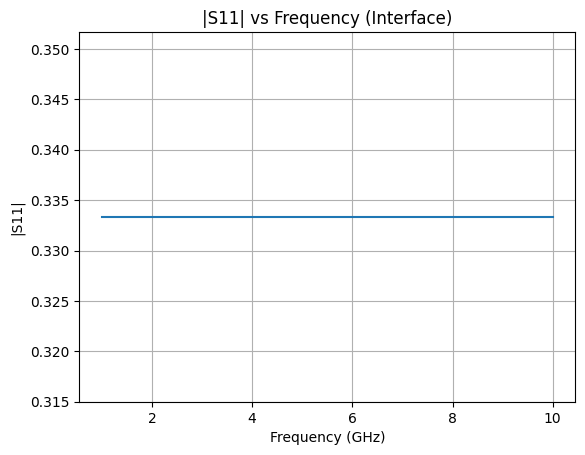

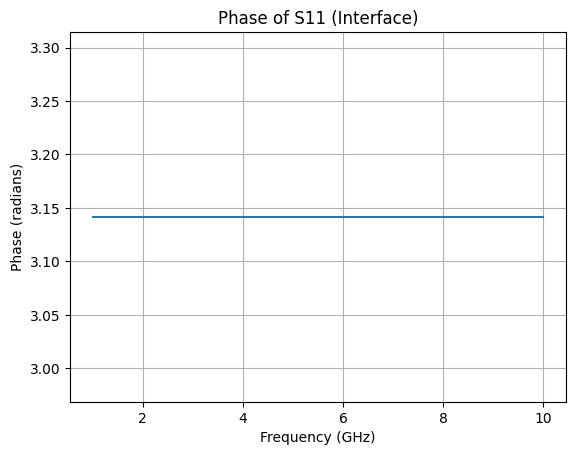

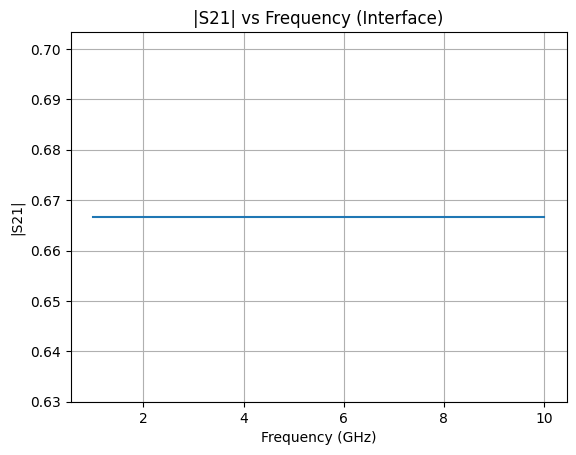

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
c = 3e8
f = np.linspace(1e9, 10e9, 500)

# Material properties
eps_r1 = 1.0   # air
eps_r2 = 4.0   # dielectric

eta0 = 377
eta1 = eta0 / np.sqrt(eps_r1)
eta2 = eta0 / np.sqrt(eps_r2)

# Reflection and transmission coefficients
r = (eta2 - eta1) / (eta2 + eta1)
t = (2 * eta2) / (eta2 + eta1)

# Create arrays (constant vs frequency)
S11 = np.full_like(f, r, dtype=complex)
S21 = np.full_like(f, t, dtype=complex)

# --- Plot 1: |S11|
plt.figure()
plt.plot(f/1e9, np.abs(S11))
plt.title("|S11| vs Frequency (Interface)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S11|")
plt.grid()

# --- Plot 2: Phase(S11)
plt.figure()
plt.plot(f/1e9, np.angle(S11))
plt.title("Phase of S11 (Interface)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Phase (radians)")
plt.grid()

# --- Plot 3: |S21|
plt.figure()
plt.plot(f/1e9, np.abs(S21))
plt.title("|S21| vs Frequency (Interface)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S21|")
plt.grid()

plt.show()

### Di-electric Slab


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_S11(eps_r=4.0, d=0.1):
    # Constants
    c = 3e8
    f = np.linspace(1e9, 10e9, 500)
    w = 2 * np.pi * f
    k0 = w / c
    k = k0 * np.sqrt(eps_r)

    # Impedances
    eta0 = 377
    eta = eta0 / np.sqrt(eps_r)

    # Reflection coefficient
    r = (eta - eta0) / (eta + eta0)

    # Total reflection
    S11 = r * (1 - np.exp(-2j * k * d)) / (1 - r**2 * np.exp(-2j * k * d))

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(f/1e9, np.abs(S11))
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("|S11|")
    plt.title(f"|S11| vs Frequency (εr={eps_r:.2f}, d={d:.3f} m)")
    plt.grid()
    plt.show()

# Sliders
interact(
    plot_S11,
    eps_r=FloatSlider(value=4.0, min=1.0, max=10.0, step=0.5),
    d=FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01)
)

interactive(children=(FloatSlider(value=4.0, description='eps_r', max=10.0, min=1.0, step=0.5), FloatSlider(va…

<function __main__.plot_S11(eps_r=4.0, d=0.1)>

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_phase_S21(eps_r=4.0, d=0.1):
    # Constants
    c = 3e8
    f = np.linspace(1e9, 10e9, 500)
    w = 2 * np.pi * f
    k0 = w / c
    k = k0 * np.sqrt(eps_r)

    # Impedances
    eta0 = 377
    eta = eta0 / np.sqrt(eps_r)

    # Reflection and transmission coefficients
    r = (eta - eta0) / (eta + eta0)
    t = (2 * eta) / (eta + eta0)

    # Transmission S21
    S21 = (t * np.exp(-1j * k * d)) / (1 - r**2 * np.exp(-2j * k * d))

    # Phase (unwrap)
    phase = np.unwrap(np.angle(S21))

    # Plot
    plt.figure(figsize=(6,4))
    plt.plot(f/1e9, phase)
    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Phase (radians)")
    plt.title(f"Phase of S21 vs Frequency (εr={eps_r:.2f}, d={d:.3f} m)")
    plt.grid()
    plt.show()

# Sliders
interact(
    plot_phase_S21,
    eps_r=FloatSlider(value=4.0, min=1.0, max=10.0, step=0.5),
    d=FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01)
)

interactive(children=(FloatSlider(value=5.0, description='f_center', max=10.0, min=1.0, step=0.5), FloatSlider…

<function __main__.plot_phase_window(f_center=5.0, bandwidth=5.0)>

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider

def plot_reflection_transmission(eps_r=4.0, d=0.1):
    # Constants
    c = 3e8
    f = np.linspace(1e9, 10e9, 500)
    w = 2 * np.pi * f
    k0 = w / c
    k = k0 * np.sqrt(eps_r)

    # Impedances
    eta0 = 377
    eta = eta0 / np.sqrt(eps_r)

    # Reflection & transmission (single interface)
    r = (eta - eta0) / (eta + eta0)
    t = (2 * eta) / (eta + eta0)

    # Slab S-parameters
    S11 = r * (1 - np.exp(-2j * k * d)) / (1 - r**2 * np.exp(-2j * k * d))
    S21 = (t * np.exp(-1j * k * d)) / (1 - r**2 * np.exp(-2j * k * d))

    # Power
    R = np.abs(S11)**2
    T = np.abs(S21)**2

    # Plot
    plt.figure(figsize=(7,4))
    plt.plot(f/1e9, R, label="Reflection |S11|^2")
    plt.plot(f/1e9, T, label="Transmission |S21|^2")

    plt.xlabel("Frequency (GHz)")
    plt.ylabel("Power Ratio")
    plt.title(f"Reflection vs Transmission (εr={eps_r:.2f}, d={d:.3f} m)")
    plt.legend()
    plt.grid()
    plt.ylim(0, 1.1)
    plt.show()

# Sliders
interact(
    plot_reflection_transmission,
    eps_r=FloatSlider(value=4.0, min=1.0, max=10.0, step=0.5),
    d=FloatSlider(value=0.1, min=0.01, max=0.5, step=0.01)
)

interactive(children=(FloatSlider(value=4.0, description='eps_r', max=10.0, min=1.0, step=0.5), FloatSlider(va…

<function __main__.plot_reflection_transmission(eps_r=4.0, d=0.1)>

### 1D toy example


Step 1: Setup
We discretize the scene into voxels and assign object reflectivity chi.
Number of voxels: 20
Voxel positions x (m):
[0.1   , 0.1474, 0.1947, 0.2421, 0.2895, 0.3368, 0.3842, 0.4316, 0.4789,
 0.5263, 0.5737, 0.6211, 0.6684, 0.7158, 0.7632, 0.8105, 0.8579, 0.9053,
 0.9526, 1.    ]
Object voxel indices: [5, 12, 16]


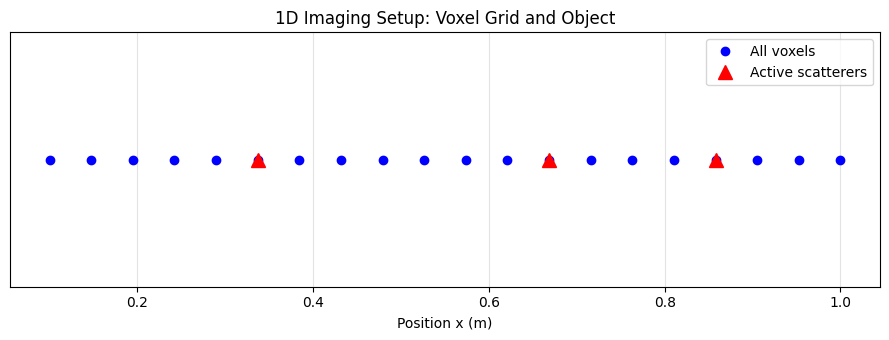


Step 2: Forward Physics
Each voxel contributes a phase-shifted signal depending on distance.
For each frequency, we compute S(f) = sum over voxels of chi_n * exp(-j 2k r_n)

------------------------------------------------------------------------
Frequency index 0: f = 1.0000 GHz, k = 20.943951 rad/m
  voxel n=00 | r_n=0.1000 m | exp(-j2kr_n)=-0.5000+0.8660j | chi_n=0.00 | contrib=-0.0000+0.0000j
  voxel n=01 | r_n=0.1474 m | exp(-j2kr_n)=+0.9939+0.1100j | chi_n=0.00 | contrib=+0.0000+0.0000j
  voxel n=02 | r_n=0.1947 m | exp(-j2kr_n)=-0.2985-0.9544j | chi_n=0.00 | contrib=+0.0000-0.0000j
  voxel n=03 | r_n=0.2421 m | exp(-j2kr_n)=-0.7541+0.6568j | chi_n=0.00 | contrib=-0.0000+0.0000j
  voxel n=04 | r_n=0.2895 m | exp(-j2kr_n)=+0.9044+0.4268j | chi_n=0.00 | contrib=+0.0000+0.0000j
  voxel n=05 | r_n=0.3368 m | exp(-j2kr_n)=+0.0276-0.9996j | chi_n=1.00 | contrib=+0.0276-0.9996j
  voxel n=06 | r_n=0.3842 m | exp(-j2kr_n)=-0.9265+0.3763j | chi_n=0.00 | contrib=-0.0000+0.0000j
  voxel n=0

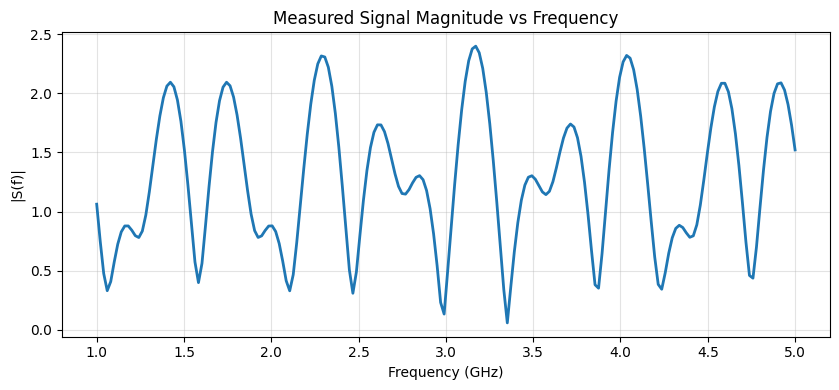


Step 4: Matrix Model A
Matrix A captures how each voxel affects each frequency.
A matrix maps object -> measurements
A[i,n] = exp(-j 2 k_i x_n)
Shape of A: (200, 20)
First 3 rows of A:
[[-0.5   +0.866j   0.9939+0.11j   -0.2985-0.9544j -0.7541+0.6568j
   0.9044+0.4268j  0.0276-0.9996j -0.9265+0.3763j  0.7168+0.6973j
   0.3506-0.9365j -0.9985+0.0551j  0.4515+0.8923j  0.6357-0.7719j
  -0.9623-0.2721j  0.1374+0.9905j  0.8519-0.5237j -0.8218-0.5698j
  -0.1917+0.9815j  0.9758-0.2187j -0.5922-0.8058j -0.5   +0.866j ]
 [-0.4254+0.905j   0.9999-0.0138j -0.4503-0.8929j -0.6055+0.7958j
   0.9806+0.1959j -0.2533-0.9674j -0.7588+0.6513j  0.9178+0.397j
  -0.045 -0.999j  -0.8784+0.4779j  0.8143+0.5805j  0.1653-0.9862j
  -0.959 +0.2833j  0.6746+0.7382j  0.3682-0.9297j -0.9971+0.0761j
   0.505 +0.8631j  0.5548-0.832j  -0.9909-0.1345j  0.313 +0.9497j]
 [-0.3478+0.9376j  0.9905-0.1375j -0.59  -0.8074j -0.4319+0.9019j
   0.9989-0.0465j -0.5138-0.8579j -0.5124+0.8587j  0.999 +0.0449j
  -0.4334-0.9012j -0.

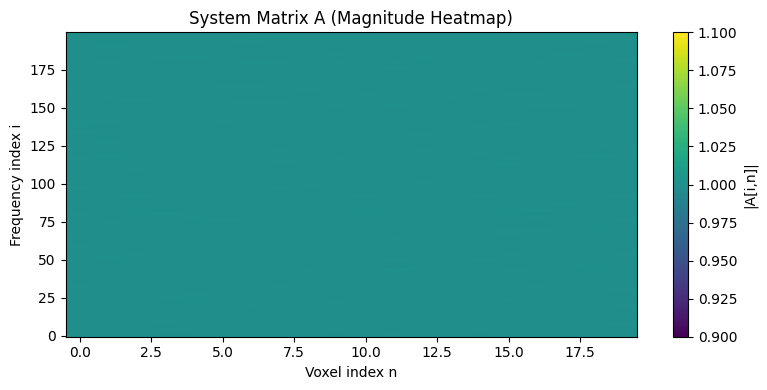


Step 5: Inverse Problem
We solve S = A * chi using least squares (pseudo-inverse)
There are more equations than unknowns, so we compute a best-fit solution.

Step 6: Reconstruction
Shape of pseudo-inverse pinv(A): (20, 200)
Condition number of A: 1.4142e+00
First few values of chi_est:
  chi_est[0] = +0.000000+0.000000j
  chi_est[1] = +0.000000+0.000000j
  chi_est[2] = +0.000000+0.000000j
  chi_est[3] = +0.000000+0.000000j
  chi_est[4] = +0.000000-0.000000j
  chi_est[5] = +1.000000+0.000000j
  chi_est[6] = -0.000000+0.000000j
  chi_est[7] = -0.000000-0.000000j


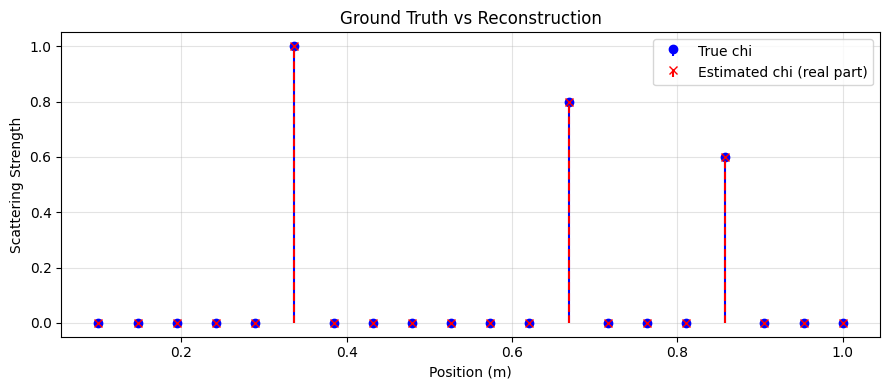


Step 7: Error Analysis
Reconstruction error per voxel is |chi_true - chi_est|.
Max error: 1.365242e-15
Mean error: 7.250794e-16


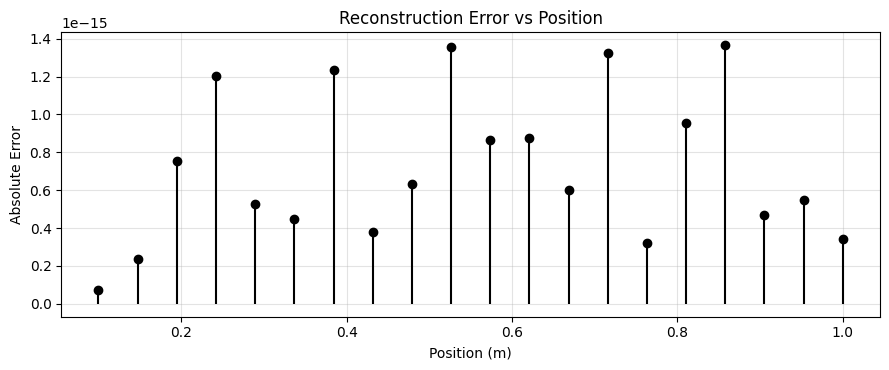

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Keep array printing compact but readable for educational console output.
np.set_printoptions(precision=4, suppress=True)


def print_step_header(step_id: int, title: str) -> None:
    print("\n" + "=" * 72)
    print(f"Step {step_id}: {title}")
    print("=" * 72)


# -----------------------------------------------------------------------------
# 1) SETUP
# -----------------------------------------------------------------------------
c = 3e8
f = np.linspace(1e9, 5e9, 200)  # frequency sweep
k = 2 * np.pi * f / c

N = 20
x = np.linspace(0.1, 1.0, N)  # 1D voxel positions (m)

chi_true = np.zeros(N, dtype=float)
chi_true[5] = 1.0
chi_true[12] = 0.8
chi_true[16] = 0.6
object_indices = np.where(chi_true > 0)[0]

print_step_header(1, "Setup")
print("We discretize the scene into voxels and assign object reflectivity chi.")
print(f"Number of voxels: {N}")
print("Voxel positions x (m):")
print(np.array2string(x, separator=", "))
print(f"Object voxel indices: {object_indices.tolist()}")

plt.figure(figsize=(9, 3.5))
plt.plot(x, np.zeros_like(x), "bo", label="All voxels")
plt.plot(x[object_indices], np.zeros_like(object_indices, dtype=float), "r^", markersize=10, label="Active scatterers")
plt.yticks([])
plt.xlabel("Position x (m)")
plt.title("1D Imaging Setup: Voxel Grid and Object")
plt.grid(alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 2) FORWARD PHYSICS
# -----------------------------------------------------------------------------
print_step_header(2, "Forward Physics")
print("Each voxel contributes a phase-shifted signal depending on distance.")
print("For each frequency, we compute S(f) = sum over voxels of chi_n * exp(-j 2k r_n)")

S = np.zeros(len(f), dtype=complex)

for i in range(len(f)):
    for n in range(N):
        S[i] += chi_true[n] * np.exp(-1j * 2 * k[i] * x[n])

# Detailed walkthrough for only the first 2 frequencies.
for i in range(2):
    print("\n" + "-" * 72)
    print(f"Frequency index {i}: f = {f[i] / 1e9:.4f} GHz, k = {k[i]:.6f} rad/m")
    running_sum = 0.0 + 0.0j

    for n in range(N):
        r_n = x[n]
        phase_term = np.exp(-1j * 2 * k[i] * r_n)
        contribution = chi_true[n] * phase_term
        running_sum += contribution

        print(
            f"  voxel n={n:02d} | r_n={r_n:.4f} m | "
            f"exp(-j2kr_n)={phase_term.real:+.4f}{phase_term.imag:+.4f}j | "
            f"chi_n={chi_true[n]:.2f} | contrib={contribution.real:+.4f}{contribution.imag:+.4f}j"
        )

    print(f"  Final S(f[{i}]) = {running_sum.real:+.6f}{running_sum.imag:+.6f}j")


# -----------------------------------------------------------------------------
# 3) FULL MEASUREMENT VIEW
# -----------------------------------------------------------------------------
print_step_header(3, "Measurement S(f)")
print("First 5 complex values of S:")
for i in range(5):
    print(f"  S[{i}] = {S[i].real:+.6f}{S[i].imag:+.6f}j")

plt.figure(figsize=(8.5, 4))
plt.plot(f / 1e9, np.abs(S), linewidth=2)
plt.xlabel("Frequency (GHz)")
plt.ylabel("|S(f)|")
plt.title("Measured Signal Magnitude vs Frequency")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 4) MATRIX MODEL
# -----------------------------------------------------------------------------
print_step_header(4, "Matrix Model A")
print("Matrix A captures how each voxel affects each frequency.")
print("A matrix maps object -> measurements")
print("A[i,n] = exp(-j 2 k_i x_n)")

A = np.zeros((len(f), N), dtype=complex)
for i in range(len(f)):
    for n in range(N):
        A[i, n] = np.exp(-1j * 2 * k[i] * x[n])

print(f"Shape of A: {A.shape}")
print("First 3 rows of A:")
print(A[:3, :])

plt.figure(figsize=(8, 4))
plt.imshow(np.abs(A), aspect="auto", origin="lower", cmap="viridis")
plt.colorbar(label="|A[i,n]|")
plt.xlabel("Voxel index n")
plt.ylabel("Frequency index i")
plt.title("System Matrix A (Magnitude Heatmap)")
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 5) INVERSE PROBLEM STATEMENT
# -----------------------------------------------------------------------------
print_step_header(5, "Inverse Problem")
print("We solve S = A * chi using least squares (pseudo-inverse)")
print("There are more equations than unknowns, so we compute a best-fit solution.")


# -----------------------------------------------------------------------------
# 6) SOLUTION
# -----------------------------------------------------------------------------
print_step_header(6, "Reconstruction")
A_pinv = np.linalg.pinv(A)
cond_A = np.linalg.cond(A)
chi_est = A_pinv @ S

print(f"Shape of pseudo-inverse pinv(A): {A_pinv.shape}")
print(f"Condition number of A: {cond_A:.4e}")
print("First few values of chi_est:")
for i in range(min(8, len(chi_est))):
    print(f"  chi_est[{i}] = {chi_est[i].real:+.6f}{chi_est[i].imag:+.6f}j")


# -----------------------------------------------------------------------------
# 7) VISUAL COMPARISON
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 4))
plt.stem(x, chi_true, linefmt="b-", markerfmt="bo", basefmt=" ", label="True chi")
plt.stem(x, np.real(chi_est), linefmt="r--", markerfmt="rx", basefmt=" ", label="Estimated chi (real part)")
plt.xlabel("Position (m)")
plt.ylabel("Scattering Strength")
plt.title("Ground Truth vs Reconstruction")
plt.legend()
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 8) ERROR ANALYSIS
# -----------------------------------------------------------------------------
print_step_header(7, "Error Analysis")
error = np.abs(chi_true - chi_est)
print("Reconstruction error per voxel is |chi_true - chi_est|.")
print(f"Max error: {np.max(error):.6e}")
print(f"Mean error: {np.mean(error):.6e}")

plt.figure(figsize=(9, 3.8))
plt.stem(x, error, linefmt="k-", markerfmt="ko", basefmt=" ")
plt.xlabel("Position (m)")
plt.ylabel("Absolute Error")
plt.title("Reconstruction Error vs Position")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()

### 1D Noisy Toy Example


Step 1: Setup
We discretize the scene into voxels and assign object reflectivity chi.
This is a monostatic setup: transmitter and receiver at same position.
Number of voxels: 20
Voxel positions x (m):
[0.1   , 0.1474, 0.1947, 0.2421, 0.2895, 0.3368, 0.3842, 0.4316, 0.4789,
 0.5263, 0.5737, 0.6211, 0.6684, 0.7158, 0.7632, 0.8105, 0.8579, 0.9053,
 0.9526, 1.    ]
Object voxel indices: [5, 12, 16]
Antenna position(s): [0.0]


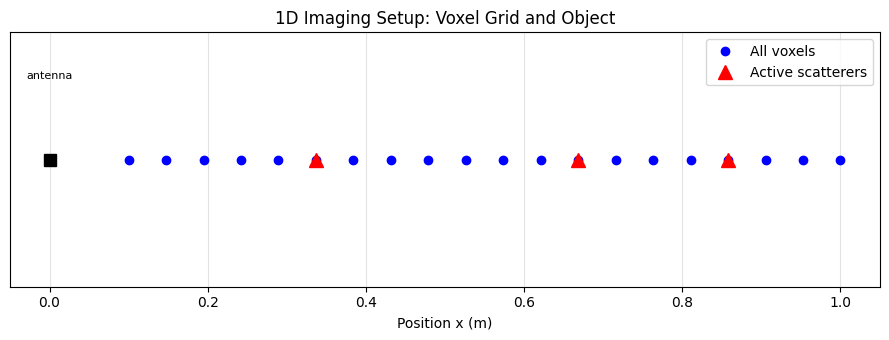


Step 2: Forward Physics
Each voxel contributes a phase-shifted signal depending on distance.
Signal decays with distance (approximate spherical spreading).
For each frequency, we compute S(f) = sum over voxels of chi_n * (1/(r_n+1e-3)) * exp(-j 2k r_n)
Added Gaussian noise to simulate measurement uncertainty.
In real systems, measurements are limited.

------------------------------------------------------------------------
Frequency index 0: f = 1.0000 GHz, k = 20.943951 rad/m
  voxel n=00 | r_n=0.1000 m | 1/(r_n+1e-3)=9.9010 | exp(-j2kr_n)=-0.5000+0.8660j | chi_n=0.00 | contrib=-0.0000+0.0000j
  voxel n=01 | r_n=0.1474 m | 1/(r_n+1e-3)=6.7400 | exp(-j2kr_n)=+0.9939+0.1100j | chi_n=0.00 | contrib=+0.0000+0.0000j
  voxel n=02 | r_n=0.1947 m | 1/(r_n+1e-3)=5.1089 | exp(-j2kr_n)=-0.2985-0.9544j | chi_n=0.00 | contrib=+0.0000-0.0000j
  voxel n=03 | r_n=0.2421 m | 1/(r_n+1e-3)=4.1134 | exp(-j2kr_n)=-0.7541+0.6568j | chi_n=0.00 | contrib=-0.0000+0.0000j
  voxel n=04 | r_n=0.2895 m | 1/(r_n

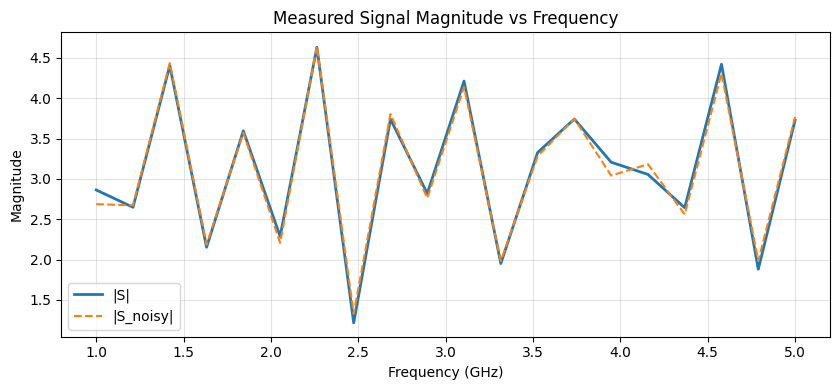


Step 4: Matrix Model A
Matrix A captures how each voxel affects each frequency.
A matrix maps object -> measurements
A[i,n] = (1 / (r_n + 1e-3)) * exp(-j 2 k_i r_n)
Shape of A: (20, 20)
First 3 rows of A:
[[-4.9505+8.5745j  6.6991+0.7415j -1.5251-4.876j  -3.102 +2.7015j
   3.1134+1.4692j  0.0816-2.9588j -2.4052+0.9769j  1.657 +1.612j
   0.7306-1.9513j -1.8935+0.1045j  0.7857+1.5526j  1.022 -1.2409j
  -1.4375-0.4065j  0.1916+1.3819j  1.1148-0.6853j -1.0126-0.7021j
  -0.2232+1.1427j  1.0767-0.2413j -0.621 -0.8449j -0.4995+0.8652j]
 [ 3.4717+9.2724j  2.5091-6.2555j -4.6011+2.2205j  3.9416+1.1766j
  -1.773 -2.951j  -0.5843+2.9017j  2.094 -1.5344j -2.2984-0.2476j
   1.3797+1.5613j  0.0303-1.8962j -1.1933+1.2665j  1.603 -0.1211j
  -1.1762-0.9209j  0.2316+1.3757j  0.7094-1.0997j -1.1914+0.3146j
   1.0319+0.5392j -0.3779-1.0367j -0.3988+0.9698j  0.9035-0.4264j]
 [ 9.3645+3.2148j -5.3546-4.0933j  2.8683+4.2277j -1.1135-3.9599j
  -0.1647+3.4387j  1.07  -2.7598j -1.6561+1.9991j  1.9623-1.222j
  

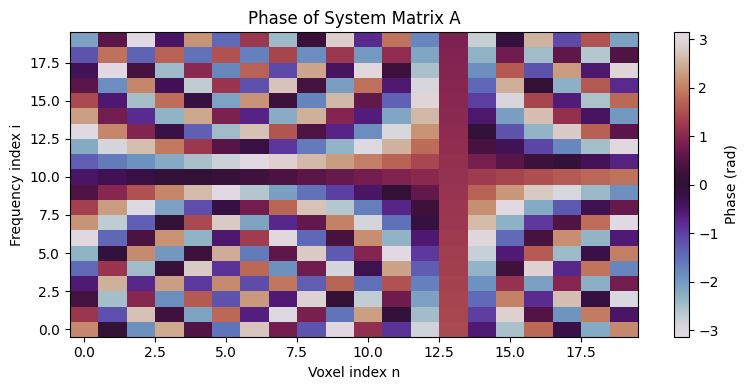


Step 5: Inverse Problem
We solve S = A * chi using least squares with Tikhonov regularization.
We stabilize the inversion because the problem is ill-posed.
There are more equations than unknowns, so we compute a best-fit solution.

Step 6: Reconstruction
Regularization strength lambda_reg: 0.2
Shape of normal-equation inverse term: (20, 20)
Condition number of A: 1.8629e+04
First few values of chi_est:
  chi_est[0] = -0.026310+0.029603j
  chi_est[1] = -0.003315+0.060513j
  chi_est[2] = -0.001636+0.031048j
  chi_est[3] = -0.007780-0.000887j
  chi_est[4] = +0.018626-0.008995j
  chi_est[5] = +1.002556+0.009313j
  chi_est[6] = +0.000712+0.000087j
  chi_est[7] = +0.013443+0.006283j
Reconstruction is imperfect due to:
  - noise
  - limited measurements
  - ill-conditioning


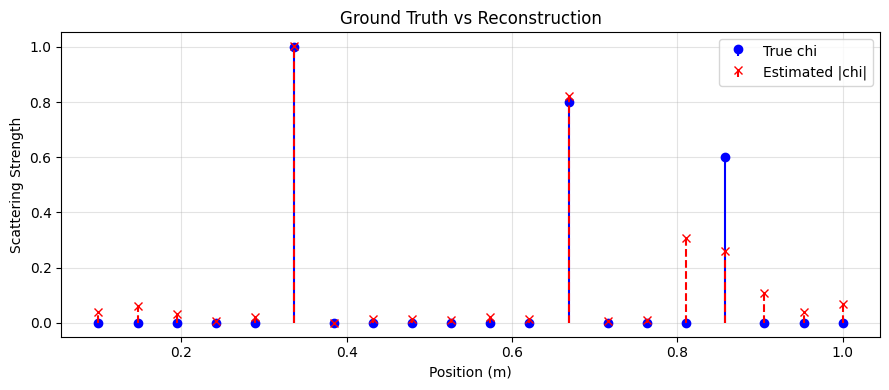


Step 7: Error Analysis
Reconstruction error per voxel is |chi_true - chi_est|.
Max error: 3.535079e-01
Mean error: 5.894545e-02


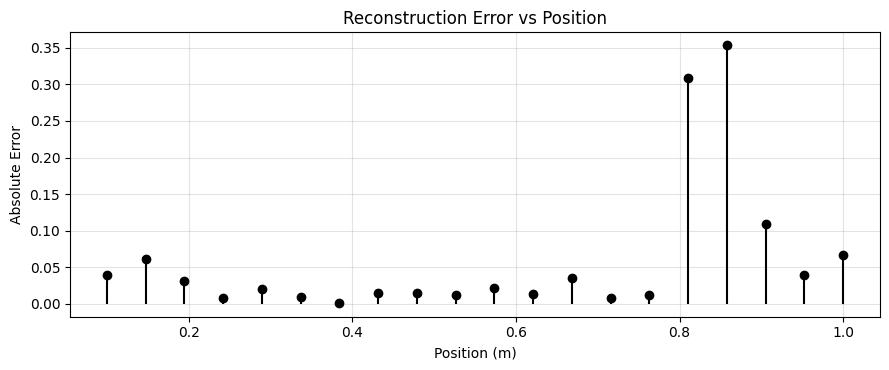

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Keep array printing compact but readable for educational console output.
np.set_printoptions(precision=4, suppress=True)

# Make the demo reproducible so the noisy reconstruction is stable in a presentation.
np.random.seed(7)


def print_step_header(step_id: int, title: str) -> None:
    print("\n" + "=" * 72)
    print(f"Step {step_id}: {title}")
    print("=" * 72)


# -----------------------------------------------------------------------------
# 1) SETUP
# -----------------------------------------------------------------------------
c = 3e8
f = np.linspace(1e9, 5e9, 20)  # real systems often have limited frequency samples
k = 2 * np.pi * f / c

N = 20
x = np.linspace(0.1, 1.0, N)  # 1D voxel positions (m)

antenna_pos = 0.0
# Optional extension: antenna_positions = [0.0, 0.2]
# Keeping the default to one antenna makes the inverse problem visibly imperfect.
antenna_positions = [antenna_pos]

chi_true = np.zeros(N, dtype=float)
chi_true[5] = 1.0
chi_true[12] = 0.8
chi_true[16] = 0.6
object_indices = np.where(chi_true > 0)[0]

print_step_header(1, "Setup")
print("We discretize the scene into voxels and assign object reflectivity chi.")
print("This is a monostatic setup: transmitter and receiver at same position.")
print(f"Number of voxels: {N}")
print("Voxel positions x (m):")
print(np.array2string(x, separator=", "))
print(f"Object voxel indices: {object_indices.tolist()}")
print(f"Antenna position(s): {antenna_positions}")

plt.figure(figsize=(9, 3.5))
plt.plot(x, np.zeros_like(x), "bo", label="All voxels")
plt.plot(x[object_indices], np.zeros_like(object_indices, dtype=float), "r^", markersize=10, label="Active scatterers")
for antenna_x in antenna_positions:
    plt.plot(antenna_x, 0.0, "ks", markersize=8)
    plt.text(antenna_x, 0.035, "antenna", ha="center", fontsize=8)
plt.yticks([])
plt.xlabel("Position x (m)")
plt.title("1D Imaging Setup: Voxel Grid and Object")
plt.grid(alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 2) FORWARD PHYSICS
# -----------------------------------------------------------------------------
print_step_header(2, "Forward Physics")
print("Each voxel contributes a phase-shifted signal depending on distance.")
print("Signal decays with distance (approximate spherical spreading).")
print("For each frequency, we compute S(f) = sum over voxels of chi_n * (1/(r_n+1e-3)) * exp(-j 2k r_n)")
print("Added Gaussian noise to simulate measurement uncertainty.")
print("In real systems, measurements are limited.")

S = np.zeros(len(f), dtype=complex)
S_stacked = np.zeros(len(f) * len(antenna_positions), dtype=complex)

for i in range(len(f)):
    for n in range(N):
        r_n = np.abs(x[n] - antenna_pos)
        S[i] += chi_true[n] * (1 / (r_n + 1e-3)) * np.exp(-1j * 2 * k[i] * r_n)

# A bit of noise helps expose the ill-posed nature of the inversion.
noise_level = 0.08
noise = noise_level * (np.random.randn(*S.shape) + 1j * np.random.randn(*S.shape))
S_noisy = S + noise

for antenna_idx, antenna_x in enumerate(antenna_positions):
    for i in range(len(f)):
        row_idx = antenna_idx * len(f) + i
        for n in range(N):
            r_n = np.abs(x[n] - antenna_x)
            S_stacked[row_idx] += chi_true[n] * (1 / (r_n + 1e-3)) * np.exp(-1j * 2 * k[i] * r_n)

noise_stacked = noise_level * (
    np.random.randn(*S_stacked.shape) + 1j * np.random.randn(*S_stacked.shape)
)
S_stacked_noisy = S_stacked + noise_stacked

# Detailed walkthrough for only the first 2 frequencies.
for i in range(2):
    print("\n" + "-" * 72)
    print(f"Frequency index {i}: f = {f[i] / 1e9:.4f} GHz, k = {k[i]:.6f} rad/m")
    running_sum = 0.0 + 0.0j

    for n in range(N):
        r_n = np.abs(x[n] - antenna_pos)
        phase_term = np.exp(-1j * 2 * k[i] * r_n)
        attenuation = 1 / (r_n + 1e-3)
        contribution = chi_true[n] * attenuation * phase_term
        running_sum += contribution

        print(
            f"  voxel n={n:02d} | r_n={r_n:.4f} m | 1/(r_n+1e-3)={attenuation:.4f} | "
            f"exp(-j2kr_n)={phase_term.real:+.4f}{phase_term.imag:+.4f}j | "
            f"chi_n={chi_true[n]:.2f} | contrib={contribution.real:+.4f}{contribution.imag:+.4f}j"
        )

    print(f"  Final S(f[{i}]) = {running_sum.real:+.6f}{running_sum.imag:+.6f}j")


# -----------------------------------------------------------------------------
# 3) FULL MEASUREMENT VIEW
# -----------------------------------------------------------------------------
print_step_header(3, "Measurement S(f)")
print("First 5 complex values of S:")
for i in range(5):
    print(f"  S[{i}] = {S[i].real:+.6f}{S[i].imag:+.6f}j")

print("Using the noisy measurement vector S_stacked_noisy for inversion.")

plt.figure(figsize=(8.5, 4))
plt.plot(f / 1e9, np.abs(S), linewidth=2)
plt.plot(f / 1e9, np.abs(S_noisy), linewidth=1.5, linestyle="--")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Magnitude")
plt.title("Measured Signal Magnitude vs Frequency")
plt.legend(["|S|", "|S_noisy|"])
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 4) MATRIX MODEL
# -----------------------------------------------------------------------------
print_step_header(4, "Matrix Model A")
print("Matrix A captures how each voxel affects each frequency.")
print("A matrix maps object -> measurements")
print("A[i,n] = (1 / (r_n + 1e-3)) * exp(-j 2 k_i r_n)")

if len(antenna_positions) > 1:
    print("Multiple antennas improve reconstruction.")

A = np.zeros((len(f) * len(antenna_positions), N), dtype=complex)
for antenna_idx, antenna_x in enumerate(antenna_positions):
    for i in range(len(f)):
        row_idx = antenna_idx * len(f) + i
        for n in range(N):
            r_n = np.abs(x[n] - antenna_x)
            A[row_idx, n] = (1 / (r_n + 1e-3)) * np.exp(-1j * 2 * k[i] * r_n)

print(f"Shape of A: {A.shape}")
print("First 3 rows of A:")
print(A[:3, :])

plt.figure(figsize=(8, 4))
plt.imshow(np.angle(A), cmap="twilight", aspect="auto", origin="lower")
plt.colorbar(label="Phase (rad)")
plt.xlabel("Voxel index n")
plt.ylabel("Frequency index i")
plt.title("Phase of System Matrix A")
print("Information is encoded in phase, not magnitude.")
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 5) INVERSE PROBLEM STATEMENT
# -----------------------------------------------------------------------------
print_step_header(5, "Inverse Problem")
print("We solve S = A * chi using least squares with Tikhonov regularization.")
print("We stabilize the inversion because the problem is ill-posed.")
print("There are more equations than unknowns, so we compute a best-fit solution.")


# -----------------------------------------------------------------------------
# 6) SOLUTION
# -----------------------------------------------------------------------------
print_step_header(6, "Reconstruction")
lambda_reg = 0.2
identity = np.eye(N)
cond_A = np.linalg.cond(A)
chi_est = np.linalg.inv(A.conj().T @ A + lambda_reg * identity) @ A.conj().T @ S_stacked_noisy

print(f"Regularization strength lambda_reg: {lambda_reg}")
print(f"Shape of normal-equation inverse term: {(A.conj().T @ A + lambda_reg * identity).shape}")
print(f"Condition number of A: {cond_A:.4e}")
print("First few values of chi_est:")
for i in range(min(8, len(chi_est))):
    print(f"  chi_est[{i}] = {chi_est[i].real:+.6f}{chi_est[i].imag:+.6f}j")

print("Reconstruction is imperfect due to:")
print("  - noise")
print("  - limited measurements")
print("  - ill-conditioning")


# -----------------------------------------------------------------------------
# 7) VISUAL COMPARISON
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 4))
plt.stem(x, chi_true, linefmt="b-", markerfmt="bo", basefmt=" ", label="True chi")
plt.stem(x, np.abs(chi_est), linefmt="r--", markerfmt="rx", basefmt=" ", label="Estimated |chi|")
plt.xlabel("Position (m)")
plt.ylabel("Scattering Strength")
plt.title("Ground Truth vs Reconstruction")
plt.legend()
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 8) ERROR ANALYSIS
# -----------------------------------------------------------------------------
print_step_header(7, "Error Analysis")
error = np.abs(chi_true - chi_est)
print("Reconstruction error per voxel is |chi_true - chi_est|.")
print(f"Max error: {np.max(error):.6e}")
print(f"Mean error: {np.mean(error):.6e}")

plt.figure(figsize=(9, 3.8))
plt.stem(x, error, linefmt="k-", markerfmt="ko", basefmt=" ")
plt.xlabel("Position (m)")
plt.ylabel("Absolute Error")
plt.title("Reconstruction Error vs Position")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()

### 1D Realistic Problem


Step 1: Setup
We discretize the scene into voxels and assign object reflectivity chi.
This represents a continuous object instead of isolated scatterers.
Multiple antennas provide more measurement diversity.
Number of voxels: 50
Voxel positions x (m):
[0.    , 0.0092, 0.0184, 0.0276, 0.0367, 0.0459, 0.0551, 0.0643, 0.0735,
 0.0827, 0.0918, 0.101 , 0.1102, 0.1194, 0.1286, 0.1378, 0.1469, 0.1561,
 0.1653, 0.1745, 0.1837, 0.1929, 0.202 , 0.2112, 0.2204, 0.2296, 0.2388,
 0.248 , 0.2571, 0.2663, 0.2755, 0.2847, 0.2939, 0.3031, 0.3122, 0.3214,
 0.3306, 0.3398, 0.349 , 0.3582, 0.3673, 0.3765, 0.3857, 0.3949, 0.4041,
 0.4133, 0.4224, 0.4316, 0.4408, 0.45  ]
Object voxel indices: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Antenna position(s): [0, 0.45]
Number of antennas: 2


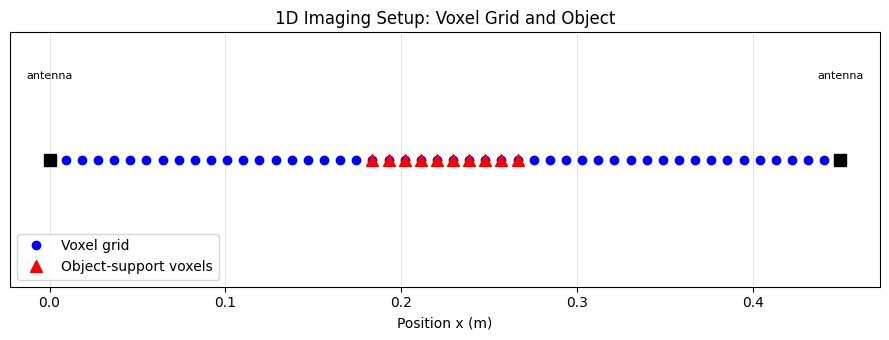

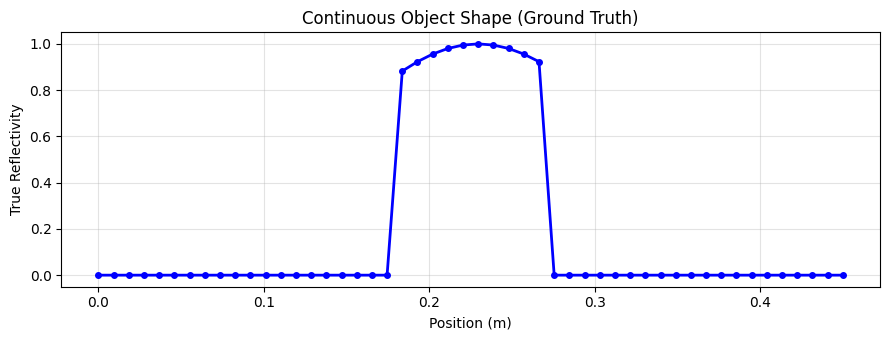


Step 2: Forward Physics
Each voxel contributes a phase-shifted signal depending on distance.
Signal decays with distance (approximate spherical spreading).
For each tx/rx pair and each frequency, we compute:
S = sum over voxels of chi_n * (1/(r_tx+1e-3)) * (1/(r_rx+1e-3)) * exp(-j k (r_tx+r_rx))
Added Gaussian noise to simulate measurement uncertainty.
In real systems, measurements are limited.

------------------------------------------------------------------------
Frequency index 0: f = 1.0000 GHz, k = 20.943951 rad/m (Tx=0.00 m, Rx=0.00 m)
  voxel n=00 | r_tx=0.0000 m | r_rx=0.0000 m | 1/(r_tx+1e-3)=1000.0000 | 1/(r_rx+1e-3)=1000.0000 | exp(-jk(r_tx+r_rx))=+1.0000+0.0000j | chi_n=0.00 | contrib=+0.0000+0.0000j
  voxel n=01 | r_tx=0.0092 m | r_rx=0.0092 m | 1/(r_tx+1e-3)=98.1964 | 1/(r_rx+1e-3)=98.1964 | exp(-jk(r_tx+r_rx))=+0.9269-0.3753j | chi_n=0.00 | contrib=+0.0000+0.0000j
  voxel n=02 | r_tx=0.0184 m | r_rx=0.0184 m | 1/(r_tx+1e-3)=51.6333 | 1/(r_rx+1e-3)=51.6333 | exp(-jk(r_

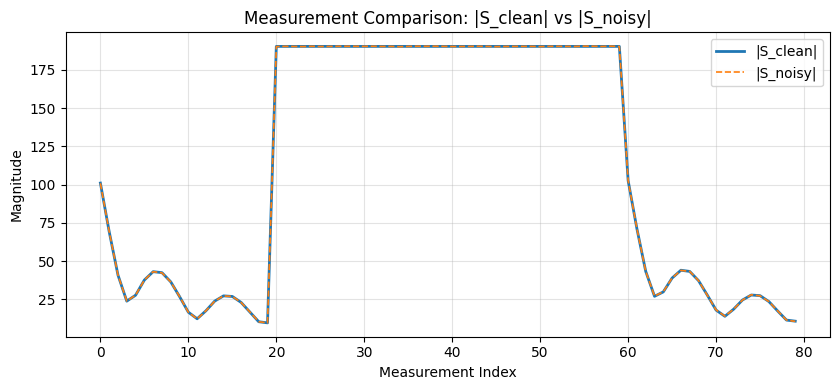


Step 4: Matrix Model A
Matrix A captures how each voxel affects each frequency.
A matrix maps object -> measurements
Each row corresponds to one (tx antenna, rx antenna, frequency) tuple.
A[row,n] = (1/(r_tx+1e-3))*(1/(r_rx+1e-3))*exp(-j k_i (r_tx+r_rx))
Shape of A: (80, 50)
First 3 rows of A:
[[1000000.       +0.j        8937.8241-3618.5239j    1915.1176-1854.6879j
      496.5687-1121.7574j      22.5096 -701.9322j    -156.889  -426.3182j
     -213.6025 -235.2001j    -211.3847 -101.7975j    -179.9497  -11.5532j
     -135.6213  +45.0294j     -88.3485  +75.2122j     -44.44    +85.1831j
       -7.7649  +80.491j       19.6318  +66.146j       37.1373  +46.5688j
       45.2563  +25.4879j      45.3164   +5.8429j      39.1816  -10.2746j
       28.9761  -21.6254j      16.8327  -27.7674j       4.6798  -28.946j
       -5.9212  -25.9423j     -13.8777  -19.8947j     -18.608   -12.1124j
      -20.023    -3.8995j     -18.4599   +3.5951j     -14.5774   +9.4888j
       -9.2306  +13.2327j      -3.3393 

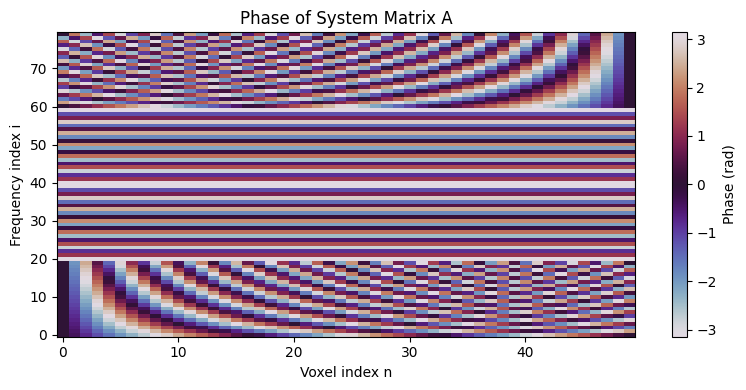


Step 5: Inverse Problem
We solve S = A * chi using least squares with Tikhonov regularization.
We stabilize the inversion because the problem is ill-posed.
There are more equations than unknowns, so we compute a best-fit solution.

Step 6: Reconstruction
Regularization strength lambda_reg: 0.2
Shape of normal-equation inverse term: (50, 50)
Condition number of A: 2.8638e+20
First few values of chi_est:
  chi_est[0] = +0.000008-0.000028j
  chi_est[1] = -0.012608+0.002293j
  chi_est[2] = +0.050326+0.049767j
  chi_est[3] = -0.049794-0.096745j
  chi_est[4] = +0.111114+0.203256j
  chi_est[5] = -0.006685-0.205951j
  chi_est[6] = +0.077719+0.167648j
  chi_est[7] = +0.105216-0.007220j
Reconstruction is imperfect due to:
  - noise
  - limited measurements
  - ill-conditioning
With multiple antennas, diversity improves reconstruction quality compared to single-antenna scans.
Single-antenna vs multi-antenna comparison:
  Mean error (single antenna): 2.605616e-01
  Mean error (multi antenna):  1.

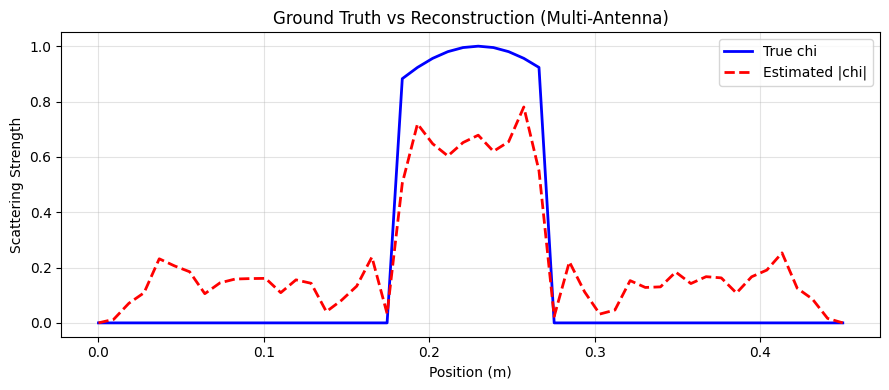


Step 7: Error Analysis
Reconstruction error per voxel is |chi_true - chi_est|.
Max error: 3.983787e-01
Mean error: 1.642729e-01


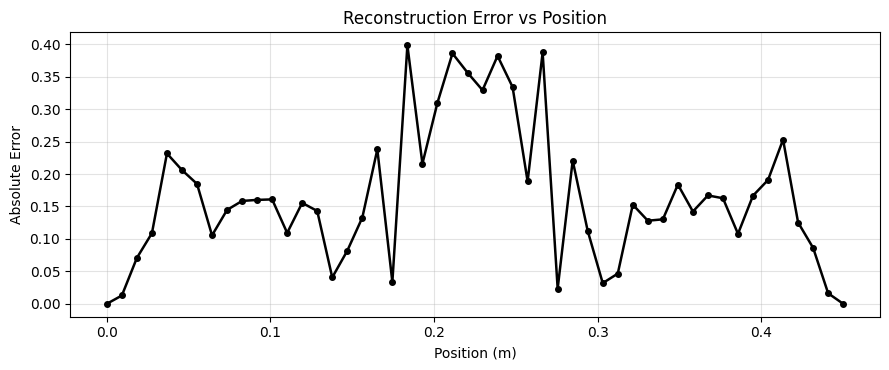

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Keep array printing compact but readable for educational console output.
np.set_printoptions(precision=4, suppress=True)

# Make the demo reproducible so the noisy reconstruction is stable in a presentation.
np.random.seed(7)


def print_step_header(step_id: int, title: str) -> None:
    print("\n" + "=" * 72)
    print(f"Step {step_id}: {title}")
    print("=" * 72)


# -----------------------------------------------------------------------------
# 1) SETUP
# -----------------------------------------------------------------------------
c = 3e8
f = np.linspace(1e9, 5e9, 20)  # real systems often have limited frequency samples
k = 2 * np.pi * f / c

N = 50
x = np.linspace(0, 0.45, N)  # 1D voxel positions (m)

antenna_positions = [ 0, 0.45]
num_antennas = len(antenna_positions)


# Create a clustered, continuous object profile instead of isolated spikes.
chi_true = np.zeros(N)

for i in range(20, 30):
    chi_true[i] = np.exp(-0.5 * ((i-25)/10)**2)

# for i in range(12, 16):
#     chi_true[i] += 0.6 * np.exp(-0.5 * ((i - 14) / 1.5) ** 2)

object_indices = np.where(chi_true > 0)[0]

print_step_header(1, "Setup")
print("We discretize the scene into voxels and assign object reflectivity chi.")
print("This represents a continuous object instead of isolated scatterers.")
print("Multiple antennas provide more measurement diversity.")
print(f"Number of voxels: {N}")
print("Voxel positions x (m):")
print(np.array2string(x, separator=", "))
print(f"Object voxel indices: {object_indices.tolist()}")
print(f"Antenna position(s): {antenna_positions}")
print(f"Number of antennas: {num_antennas}")

plt.figure(figsize=(9, 3.5))
plt.plot(x, np.zeros_like(x), "bo", label="Voxel grid")
plt.plot(x[object_indices], np.zeros_like(object_indices, dtype=float), "r^", markersize=8, label="Object-support voxels")
for antenna_x in antenna_positions:
    plt.plot(antenna_x, 0.0, "ks", markersize=8)
    plt.text(antenna_x, 0.035, "antenna", ha="center", fontsize=8)
plt.yticks([])
plt.xlabel("Position x (m)")
plt.title("1D Imaging Setup: Voxel Grid and Object")
plt.grid(alpha=0.35)
plt.legend()
plt.tight_layout()
plt.show()

# Plot 1: continuous object profile for presentation clarity.
plt.figure(figsize=(9, 3.5))
plt.plot(x, chi_true, "b-o", linewidth=2, markersize=4)
plt.xlabel("Position (m)")
plt.ylabel("True Reflectivity")
plt.title("Continuous Object Shape (Ground Truth)")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 2) FORWARD PHYSICS
# -----------------------------------------------------------------------------
print_step_header(2, "Forward Physics")
print("Each voxel contributes a phase-shifted signal depending on distance.")
print("Signal decays with distance (approximate spherical spreading).")
print("For each tx/rx pair and each frequency, we compute:")
print("S = sum over voxels of chi_n * (1/(r_tx+1e-3)) * (1/(r_rx+1e-3)) * exp(-j k (r_tx+r_rx))")
print("Added Gaussian noise to simulate measurement uncertainty.")
print("In real systems, measurements are limited.")

num_freq = len(f)
num_measurements = num_antennas * num_antennas * num_freq
S_clean = np.zeros(num_measurements, dtype=complex)

for tx_idx, tx_pos in enumerate(antenna_positions):
    for rx_idx, rx_pos in enumerate(antenna_positions):
        for i in range(num_freq):
            row_idx = tx_idx * (num_antennas * num_freq) + rx_idx * num_freq + i
            for n in range(N):
                r_tx = np.abs(x[n] - tx_pos)
                r_rx = np.abs(x[n] - rx_pos)
                contribution = (
                    chi_true[n]
                    * (1 / (r_tx + 1e-3))
                    * (1 / (r_rx + 1e-3))
                    * np.exp(-1j * k[i] * (r_tx + r_rx))
                )
                S_clean[row_idx] += contribution

# A bit of noise helps expose the ill-posed nature of the inversion.
noise_level = 0.08
noise = noise_level * (np.random.randn(*S_clean.shape) + 1j * np.random.randn(*S_clean.shape))
S_noisy = S_clean + noise

# Detailed walkthrough for only the first 2 frequencies.
tx_pos_demo = antenna_positions[0]
rx_pos_demo = antenna_positions[0]
for i in range(2):
    print("\n" + "-" * 72)
    print(
        f"Frequency index {i}: f = {f[i] / 1e9:.4f} GHz, k = {k[i]:.6f} rad/m "
        f"(Tx={tx_pos_demo:.2f} m, Rx={rx_pos_demo:.2f} m)"
    )
    running_sum = 0.0 + 0.0j

    for n in range(N):
        r_tx = np.abs(x[n] - tx_pos_demo)
        r_rx = np.abs(x[n] - rx_pos_demo)
        attenuation_tx = 1 / (r_tx + 1e-3)
        attenuation_rx = 1 / (r_rx + 1e-3)
        phase_term = np.exp(-1j * k[i] * (r_tx + r_rx))
        contribution = chi_true[n] * attenuation_tx * attenuation_rx * phase_term
        running_sum += contribution

        print(
            f"  voxel n={n:02d} | r_tx={r_tx:.4f} m | r_rx={r_rx:.4f} m | "
            f"1/(r_tx+1e-3)={attenuation_tx:.4f} | 1/(r_rx+1e-3)={attenuation_rx:.4f} | "
            f"exp(-jk(r_tx+r_rx))={phase_term.real:+.4f}{phase_term.imag:+.4f}j | "
            f"chi_n={chi_true[n]:.2f} | contrib={contribution.real:+.4f}{contribution.imag:+.4f}j"
        )

    print(f"  Final S(f[{i}]) = {running_sum.real:+.6f}{running_sum.imag:+.6f}j")


# -----------------------------------------------------------------------------
# 3) FULL MEASUREMENT VIEW
# -----------------------------------------------------------------------------
print_step_header(3, "Measurement S(f)")
print("First 5 complex values of S_clean:")
for i in range(5):
    print(f"  S_clean[{i}] = {S_clean[i].real:+.6f}{S_clean[i].imag:+.6f}j")

print(f"Total number of measurements: {num_measurements} (= Ntx * Nrx * Nf)")
print("Using the noisy measurement vector S_noisy for inversion.")
print("With multiple antennas, reconstruction should be smoother and more accurate than single-antenna data.")

plt.figure(figsize=(8.5, 4))
plt.plot(np.abs(S_clean), linewidth=2)
plt.plot(np.abs(S_noisy), linewidth=1.2, linestyle="--")
plt.xlabel("Measurement Index")
plt.ylabel("Magnitude")
plt.title("Measurement Comparison: |S_clean| vs |S_noisy|")
plt.legend(["|S_clean|", "|S_noisy|"])
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 4) MATRIX MODEL
# -----------------------------------------------------------------------------
print_step_header(4, "Matrix Model A")
print("Matrix A captures how each voxel affects each frequency.")
print("A matrix maps object -> measurements")
print("Each row corresponds to one (tx antenna, rx antenna, frequency) tuple.")
print("A[row,n] = (1/(r_tx+1e-3))*(1/(r_rx+1e-3))*exp(-j k_i (r_tx+r_rx))")

A = np.zeros((num_measurements, N), dtype=complex)
for tx_idx, tx_pos in enumerate(antenna_positions):
    for rx_idx, rx_pos in enumerate(antenna_positions):
        for i in range(num_freq):
            row_idx = tx_idx * (num_antennas * num_freq) + rx_idx * num_freq + i
            for n in range(N):
                r_tx = np.abs(x[n] - tx_pos)
                r_rx = np.abs(x[n] - rx_pos)
                A[row_idx, n] = (
                    (1 / (r_tx + 1e-3))
                    * (1 / (r_rx + 1e-3))
                    * np.exp(-1j * k[i] * (r_tx + r_rx))
                )

print(f"Shape of A: {A.shape}")
print("First 3 rows of A:")
print(A[:3, :])

plt.figure(figsize=(8, 4))
plt.imshow(np.angle(A), cmap="twilight", aspect="auto", origin="lower")
plt.colorbar(label="Phase (rad)")
plt.xlabel("Voxel index n")
plt.ylabel("Frequency index i")
plt.title("Phase of System Matrix A")
print("Information is encoded in phase, not magnitude.")
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 5) INVERSE PROBLEM STATEMENT
# -----------------------------------------------------------------------------
print_step_header(5, "Inverse Problem")
print("We solve S = A * chi using least squares with Tikhonov regularization.")
print("We stabilize the inversion because the problem is ill-posed.")
print("There are more equations than unknowns, so we compute a best-fit solution.")


# -----------------------------------------------------------------------------
# 6) SOLUTION
# -----------------------------------------------------------------------------
print_step_header(6, "Reconstruction")
lambda_reg = 0.2
identity = np.eye(N)
cond_A = np.linalg.cond(A)
chi_est = np.linalg.inv(A.conj().T @ A + lambda_reg * identity) @ A.conj().T @ S_noisy

# Baseline for interpretation: single-antenna (first Tx/Rx pair only).
A_single = A[:num_freq, :]
S_single_noisy = S_noisy[:num_freq]
chi_est_single = (
    np.linalg.inv(A_single.conj().T @ A_single + lambda_reg * identity)
    @ A_single.conj().T
    @ S_single_noisy
)

print(f"Regularization strength lambda_reg: {lambda_reg}")
print(f"Shape of normal-equation inverse term: {(A.conj().T @ A + lambda_reg * identity).shape}")
print(f"Condition number of A: {cond_A:.4e}")
print("First few values of chi_est:")
for i in range(min(8, len(chi_est))):
    print(f"  chi_est[{i}] = {chi_est[i].real:+.6f}{chi_est[i].imag:+.6f}j")

print("Reconstruction is imperfect due to:")
print("  - noise")
print("  - limited measurements")
print("  - ill-conditioning")
print("With multiple antennas, diversity improves reconstruction quality compared to single-antenna scans.")

error_multi = np.abs(chi_true - chi_est)
error_single = np.abs(chi_true - chi_est_single)
mean_err_multi = np.mean(error_multi)
mean_err_single = np.mean(error_single)
max_err_multi = np.max(error_multi)
max_err_single = np.max(error_single)

print("Single-antenna vs multi-antenna comparison:")
print(f"  Mean error (single antenna): {mean_err_single:.6e}")
print(f"  Mean error (multi antenna):  {mean_err_multi:.6e}")
print(f"  Max error  (single antenna): {max_err_single:.6e}")
print(f"  Max error  (multi antenna):  {max_err_multi:.6e}")

if mean_err_multi < mean_err_single:
    improvement = 100.0 * (mean_err_single - mean_err_multi) / (mean_err_single + 1e-12)
    print(f"  Improvement from multiple antennas: {improvement:.2f}% lower mean error")
else:
    print("  In this noise realization, multi-antenna did not outperform single-antenna by mean error.")


# -----------------------------------------------------------------------------
# 7) VISUAL COMPARISON
# -----------------------------------------------------------------------------
plt.figure(figsize=(9, 4))
plt.plot(x, chi_true, "b-", linewidth=2, label="True chi")
plt.plot(x, np.abs(chi_est), "r--", linewidth=2, label="Estimated |chi|")
plt.xlabel("Position (m)")
plt.ylabel("Scattering Strength")
plt.title("Ground Truth vs Reconstruction (Multi-Antenna)")
plt.legend()
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 8) ERROR ANALYSIS
# -----------------------------------------------------------------------------
print_step_header(7, "Error Analysis")
error = error_multi
print("Reconstruction error per voxel is |chi_true - chi_est|.")
print(f"Max error: {np.max(error):.6e}")
print(f"Mean error: {np.mean(error):.6e}")

plt.figure(figsize=(9, 3.8))
plt.plot(x, error, "k-o", linewidth=1.8, markersize=4)
plt.xlabel("Position (m)")
plt.ylabel("Absolute Error")
plt.title("Reconstruction Error vs Position")
plt.grid(alpha=0.35)
plt.tight_layout()
plt.show()

### 1D Realistic Comparision Simulation

SETUP: Global Voxel Grid and Object
Number of voxels: 50
Voxel range: 0.00 m to 0.45 m
Object support indices: [20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Frequency range: 1.0 GHz to 5.0 GHz


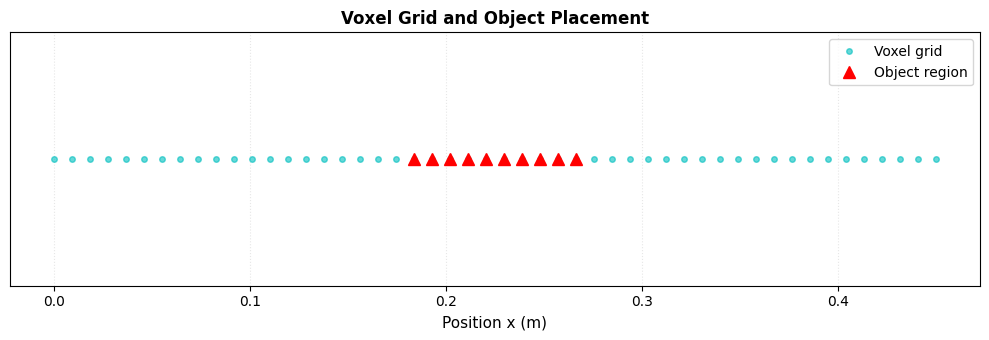

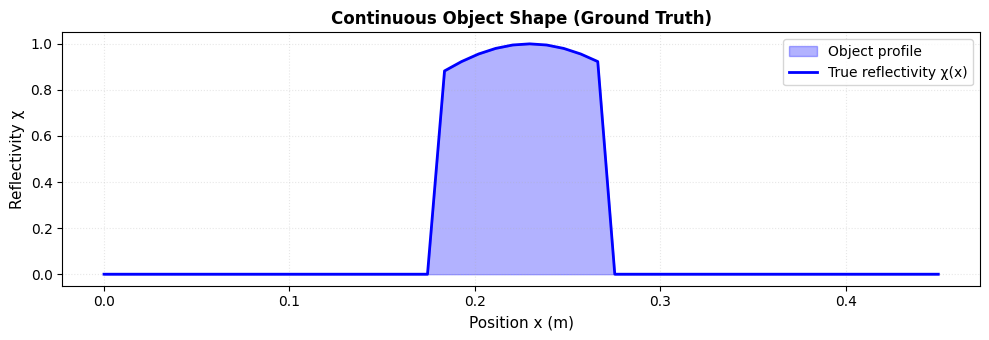


Experiment 1: Single Antenna Configuration
Antenna positions: [0.0]
Matrix A shape: (20, 50)
Condition number: 4.4964e+08
Mean error: 2.557783e-01
Max error:  9.162198e-01


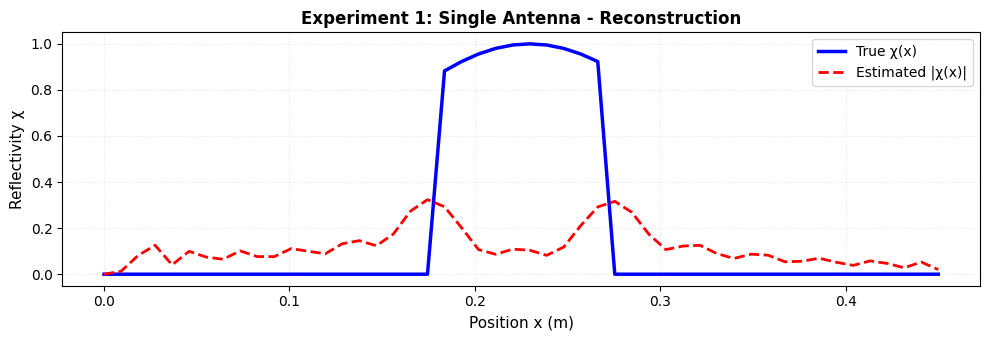

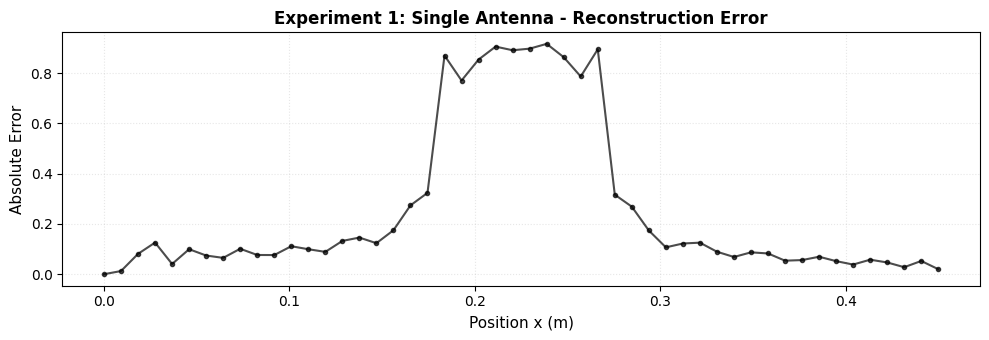

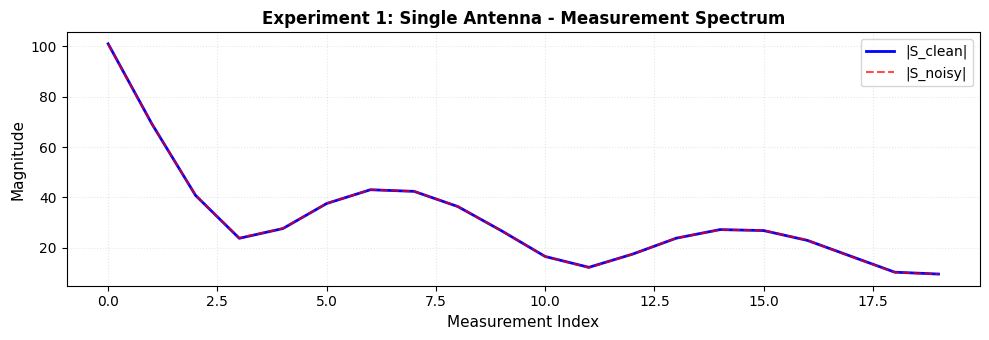

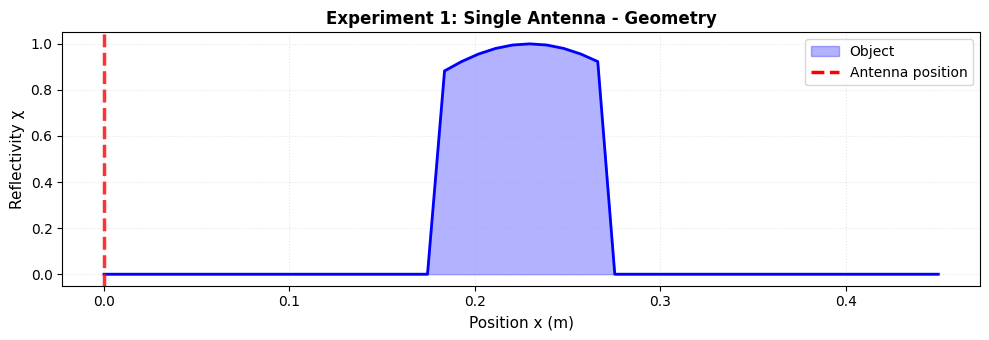

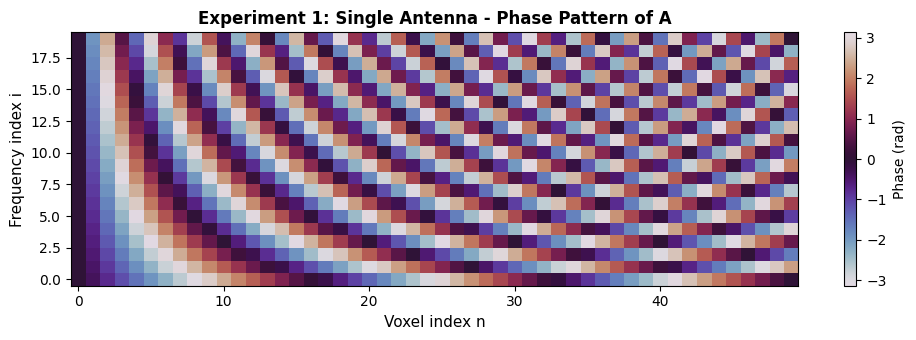


Phase Statistics (Experiment 1):
  Phase range: [-3.1382, 3.1382] rad
  Phase mean: -0.0440 rad
  Phase std: 1.8057 rad

Experiment 2: Two Antennas (Symmetric Placement)
Antenna positions: [0.0, 0.45]
Object center: ~0.230 m
Matrix A shape: (80, 50)
Condition number: 2.8638e+20
Mean error: 1.529612e-01
Max error:  3.973370e-01


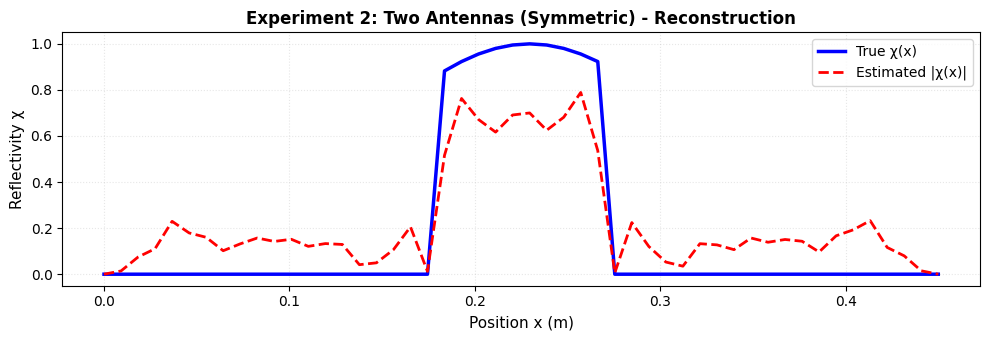

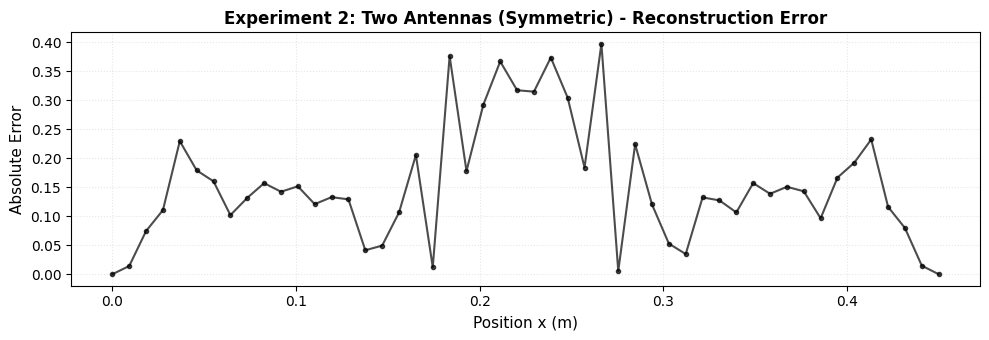

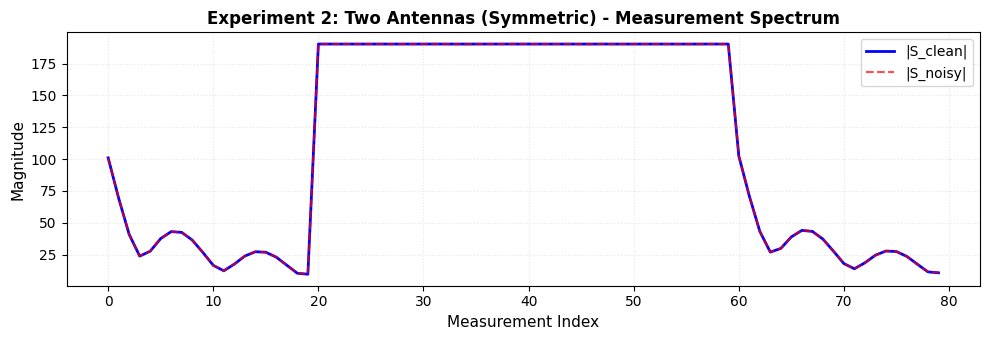

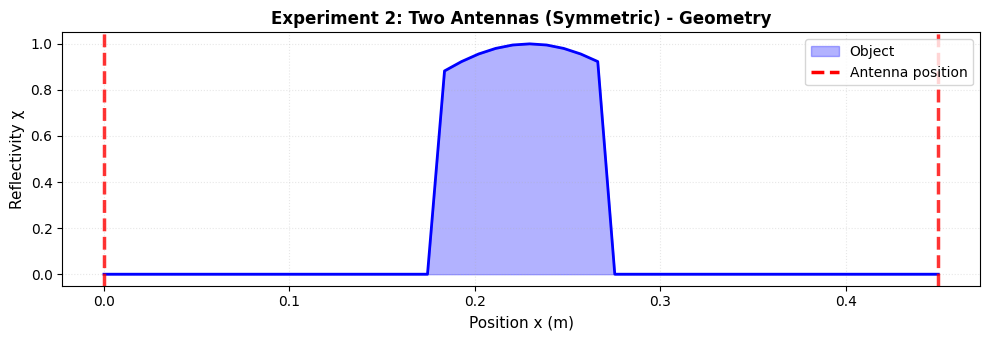

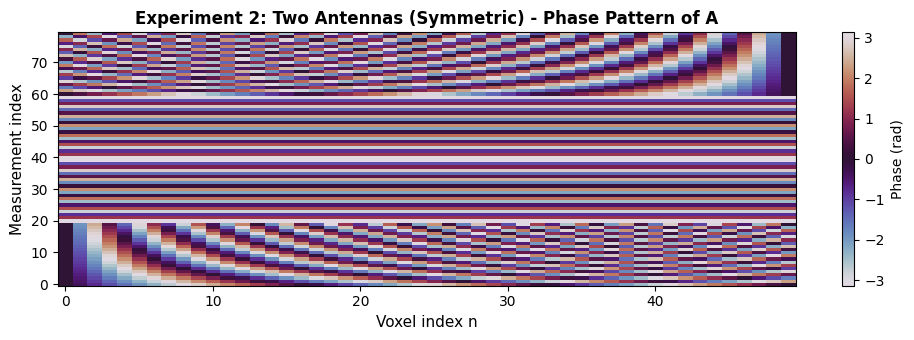


Phase Statistics (Experiment 2):
  Phase range: [-3.1416, 3.1382] rad
  Phase mean: -0.1791 rad
  Phase std: 1.8486 rad

Experiment 3: Two Antennas (Asymmetric Placement)
Antenna positions: [0.0, 0.3]
Object center: ~0.230 m
Note: Object is NOT centered between antennas
Matrix A shape: (80, 50)
Condition number: 9.1551e+14
Mean error: 7.820172e-02
Max error:  3.522203e-01


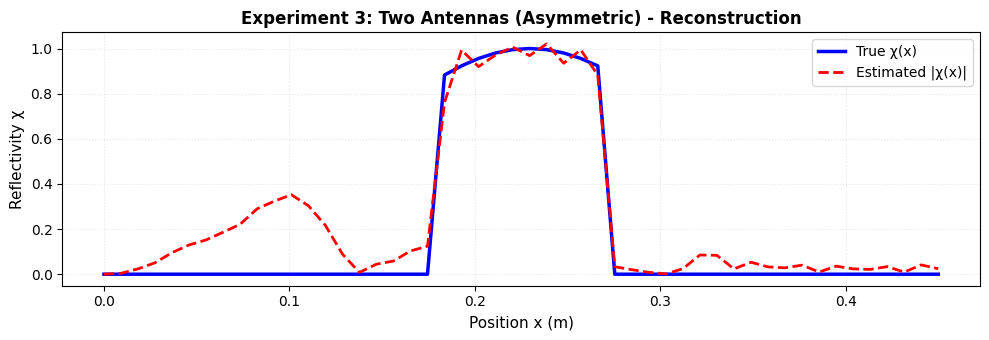

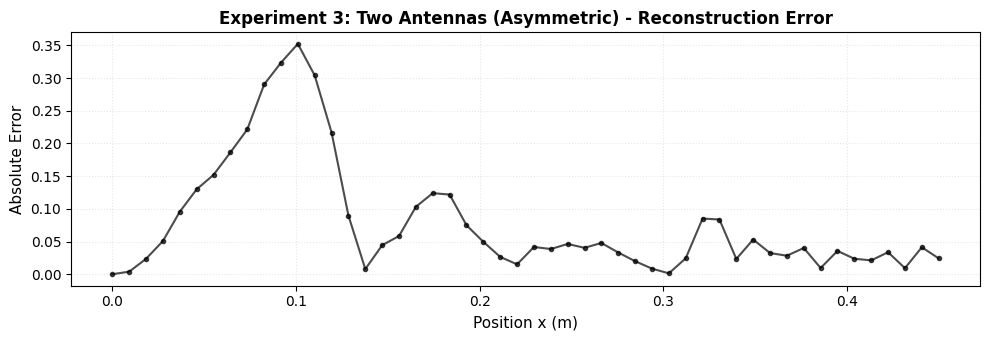

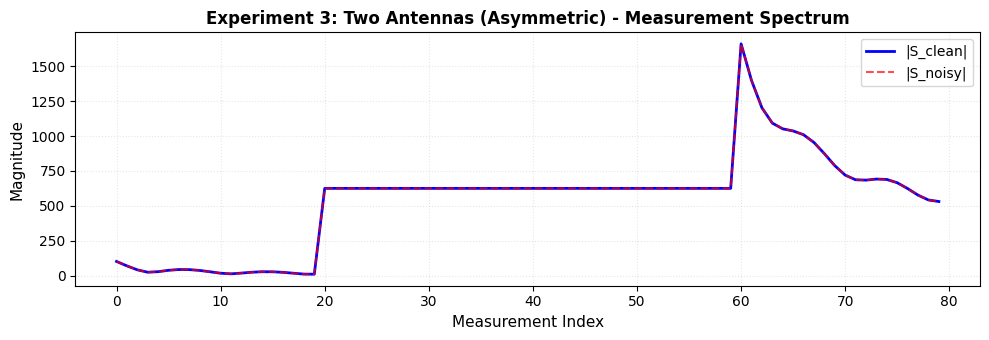

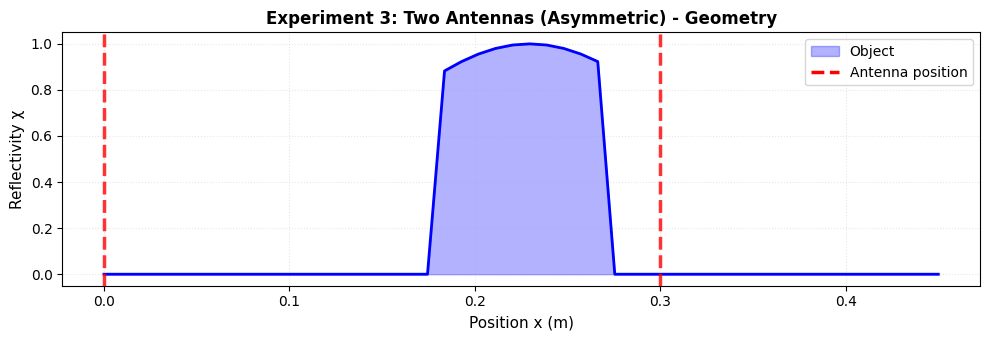

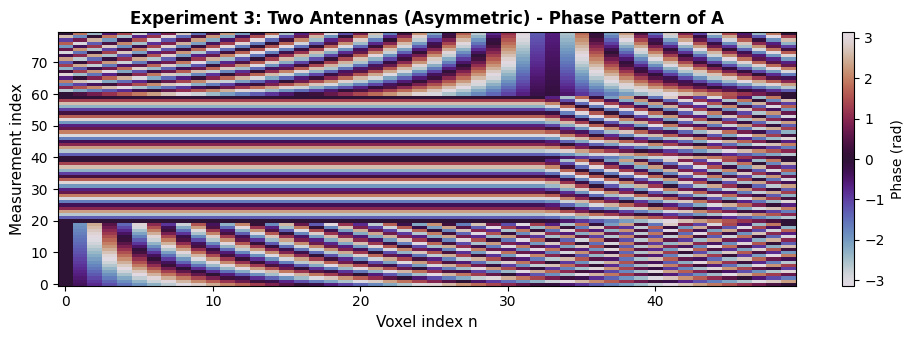


Phase Statistics (Experiment 3):
  Phase range: [-3.1382, 3.1382] rad
  Phase mean: -0.0387 rad
  Phase std: 1.7949 rad

COMPARISON SUMMARY

Reconstruction Error Metrics:
------------------------------------------------------------------------
Configuration                  Mean Error           Max Error           
------------------------------------------------------------------------
Single antenna                 2.557783e-01         9.162198e-01        
Two antennas symmetric         1.529612e-01         3.973370e-01        
Two antennas asymmetric        7.820172e-02         3.522203e-01        

Condition Numbers:
------------------------------------------------------------------------
Configuration                  Condition Number    
------------------------------------------------------------------------
Single antenna                 4.4964e+08          
Two antennas symmetric         2.8638e+20          
Two antennas asymmetric        9.1551e+14          

Improvement (sy

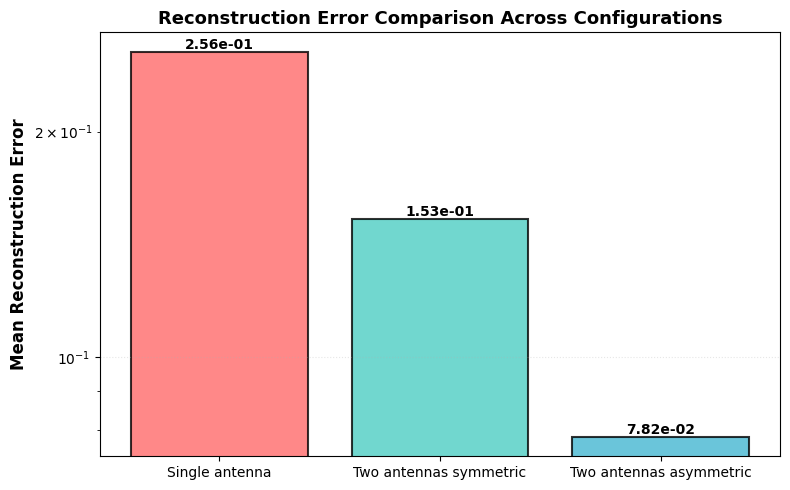


KEY INSIGHTS:
1. Single antenna: Limited reconstruction due to few measurements.
2. Symmetric antennas: Improved reconstruction with better measurement diversity.
3. Asymmetric antennas: Performance depends on antenna-object geometry.

>> Antenna placement and diversity DIRECTLY affect reconstruction quality.


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Keep array printing compact but readable for educational console output.
np.set_printoptions(precision=4, suppress=True)

# Make the demo reproducible so the noisy reconstruction is stable in a presentation.
np.random.seed(42)


def print_experiment_header(exp_num: int, title: str) -> None:
    print("\n" + "=" * 72)
    print(f"Experiment {exp_num}: {title}")
    print("=" * 72)


# =============================================================================
# GLOBAL PARAMETERS
# =============================================================================
c = 3e8
f = np.linspace(1e9, 5e9, 20)
k = 2 * np.pi * f / c

N = 50
x = np.linspace(0, 0.45, N)

noise_level = 0.08
lambda_reg = 0.2

# Define true object (same for all experiments)
chi_true = np.zeros(N)
for i in range(20, 30):
    chi_true[i] = np.exp(-0.5 * ((i - 25) / 10) ** 2)

object_indices = np.where(chi_true > 0)[0]


# =============================================================================
# STEP 1: SETUP VISUALIZATION
# =============================================================================
print("=" * 72)
print("SETUP: Global Voxel Grid and Object")
print("=" * 72)
print(f"Number of voxels: {N}")
print(f"Voxel range: {x[0]:.2f} m to {x[-1]:.2f} m")
print(f"Object support indices: {object_indices.tolist()}")
print(f"Frequency range: {f[0]/1e9:.1f} GHz to {f[-1]/1e9:.1f} GHz")

plt.figure(figsize=(10, 3.5))
plt.plot(x, np.zeros_like(x), "co", alpha=0.6, markersize=4, label="Voxel grid")
plt.plot(x[object_indices], np.zeros_like(object_indices, dtype=float), "r^", markersize=8, label="Object region")
plt.yticks([])
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("")
plt.title("Voxel Grid and Object Placement", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3, linestyle=":")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.5))
plt.fill_between(x, 0, chi_true, alpha=0.3, color="blue", label="Object profile")
plt.plot(x, chi_true, "b-", linewidth=2, label="True reflectivity χ(x)")
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Reflectivity χ", fontsize=11)
plt.title("Continuous Object Shape (Ground Truth)", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# STEP 2: DEFINE COMMON FUNCTIONS
# =============================================================================
def simulate_S(antenna_positions, x, chi_true, f, k, noise_level):
    """Simulate noisy measurement vector S."""
    num_antennas = len(antenna_positions)
    num_freq = len(f)
    num_measurements = num_antennas * num_antennas * num_freq
    S_clean = np.zeros(num_measurements, dtype=complex)

    for tx_idx, tx_pos in enumerate(antenna_positions):
        for rx_idx, rx_pos in enumerate(antenna_positions):
            for i in range(num_freq):
                row_idx = tx_idx * (num_antennas * num_freq) + rx_idx * num_freq + i
                for n in range(len(x)):
                    r_tx = np.abs(x[n] - tx_pos)
                    r_rx = np.abs(x[n] - rx_pos)
                    contribution = (
                        chi_true[n]
                        * (1 / (r_tx + 1e-3))
                        * (1 / (r_rx + 1e-3))
                        * np.exp(-1j * k[i] * (r_tx + r_rx))
                    )
                    S_clean[row_idx] += contribution

    noise = noise_level * (
        np.random.randn(*S_clean.shape) + 1j * np.random.randn(*S_clean.shape)
    )
    S_noisy = S_clean + noise
    return S_clean, S_noisy


def build_A(antenna_positions, x, f, k):
    """Build system matrix A."""
    num_antennas = len(antenna_positions)
    num_freq = len(f)
    num_measurements = num_antennas * num_antennas * num_freq
    N = len(x)
    A = np.zeros((num_measurements, N), dtype=complex)

    for tx_idx, tx_pos in enumerate(antenna_positions):
        for rx_idx, rx_pos in enumerate(antenna_positions):
            for i in range(num_freq):
                row_idx = tx_idx * (num_antennas * num_freq) + rx_idx * num_freq + i
                for n in range(N):
                    r_tx = np.abs(x[n] - tx_pos)
                    r_rx = np.abs(x[n] - rx_pos)
                    A[row_idx, n] = (
                        (1 / (r_tx + 1e-3))
                        * (1 / (r_rx + 1e-3))
                        * np.exp(-1j * k[i] * (r_tx + r_rx))
                    )
    return A


def reconstruct(A, S_noisy, lambda_reg, N):
    """Reconstruct chi using regularized least squares."""
    identity = np.eye(N)
    chi_est = (
        np.linalg.inv(A.conj().T @ A + lambda_reg * identity)
        @ A.conj().T
        @ S_noisy
    )
    return chi_est


def compute_error(chi_true, chi_est):
    """Compute reconstruction error metrics."""
    error = np.abs(chi_true - chi_est)
    mean_error = np.mean(error)
    max_error = np.max(error)
    return error, mean_error, max_error


# =============================================================================
# STORAGE FOR RESULTS
# =============================================================================
results = {}


# =============================================================================
# EXPERIMENT 1: SINGLE ANTENNA
# =============================================================================
print_experiment_header(1, "Single Antenna Configuration")
antenna_config_1 = [0.0]
print(f"Antenna positions: {antenna_config_1}")

S_clean_1, S_noisy_1 = simulate_S(antenna_config_1, x, chi_true, f, k, noise_level)
A_1 = build_A(antenna_config_1, x, f, k)
chi_est_1 = reconstruct(A_1, S_noisy_1, lambda_reg, N)
error_1, mean_err_1, max_err_1 = compute_error(chi_true, chi_est_1)

print(f"Matrix A shape: {A_1.shape}")
print(f"Condition number: {np.linalg.cond(A_1):.4e}")
print(f"Mean error: {mean_err_1:.6e}")
print(f"Max error:  {max_err_1:.6e}")

# Plot 1: Ground truth vs reconstruction
plt.figure(figsize=(10, 3.5))
plt.plot(x, chi_true, "b-", linewidth=2.5, label="True χ(x)")
plt.plot(x, np.abs(chi_est_1), "r--", linewidth=2, label="Estimated |χ(x)|")
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Reflectivity χ", fontsize=11)
plt.title("Experiment 1: Single Antenna - Reconstruction", fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 2: Error
plt.figure(figsize=(10, 3.5))
plt.plot(x, error_1, "k-o", linewidth=1.5, markersize=3, alpha=0.7)
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Absolute Error", fontsize=11)
plt.title("Experiment 1: Single Antenna - Reconstruction Error", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 3: Measurement spectrum
plt.figure(figsize=(10, 3.5))
plt.plot(np.abs(S_clean_1), "b-", linewidth=2, label="|S_clean|")
plt.plot(np.abs(S_noisy_1), "r--", linewidth=1.5, alpha=0.7, label="|S_noisy|")
plt.xlabel("Measurement Index", fontsize=11)
plt.ylabel("Magnitude", fontsize=11)
plt.title("Experiment 1: Single Antenna - Measurement Spectrum", fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 4: Antenna positions relative to object
plt.figure(figsize=(10, 3.5))
plt.fill_between(x, 0, chi_true, alpha=0.3, color="blue", label="Object")
plt.plot(x, chi_true, "b-", linewidth=2)
for ant_pos in antenna_config_1:
    plt.axvline(ant_pos, color="red", linestyle="--", linewidth=2.5, alpha=0.8)
plt.plot([], [], "r--", linewidth=2.5, label="Antenna position")
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Reflectivity χ", fontsize=11)
plt.title("Experiment 1: Single Antenna - Geometry", fontsize=12, fontweight="bold")
plt.legend(fontsize=10, loc="upper right")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 5: Phase pattern of system matrix
plt.figure(figsize=(10, 3.5))
plt.imshow(np.angle(A_1), cmap="twilight", aspect="auto", origin="lower")
plt.colorbar(label="Phase (rad)")
plt.xlabel("Voxel index n", fontsize=11)
plt.ylabel("Frequency index i", fontsize=11)
plt.title("Experiment 1: Single Antenna - Phase Pattern of A", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nPhase Statistics (Experiment 1):")
print(f"  Phase range: [{np.min(np.angle(A_1)):.4f}, {np.max(np.angle(A_1)):.4f}] rad")
print(f"  Phase mean: {np.mean(np.angle(A_1)):.4f} rad")
print(f"  Phase std: {np.std(np.angle(A_1)):.4f} rad")

results["Single antenna"] = {
    "mean_error": mean_err_1,
    "max_error": max_err_1,
    "cond_A": np.linalg.cond(A_1),
}


# =============================================================================
# EXPERIMENT 2: TWO ANTENNAS (SYMMETRIC)
# =============================================================================
print_experiment_header(2, "Two Antennas (Symmetric Placement)")
antenna_config_2 = [0.0, 0.45]
print(f"Antenna positions: {antenna_config_2}")
print(f"Object center: ~{x[object_indices[len(object_indices)//2]]:.3f} m")

S_clean_2, S_noisy_2 = simulate_S(antenna_config_2, x, chi_true, f, k, noise_level)
A_2 = build_A(antenna_config_2, x, f, k)
chi_est_2 = reconstruct(A_2, S_noisy_2, lambda_reg, N)
error_2, mean_err_2, max_err_2 = compute_error(chi_true, chi_est_2)

print(f"Matrix A shape: {A_2.shape}")
print(f"Condition number: {np.linalg.cond(A_2):.4e}")
print(f"Mean error: {mean_err_2:.6e}")
print(f"Max error:  {max_err_2:.6e}")

# Plot 1: Ground truth vs reconstruction
plt.figure(figsize=(10, 3.5))
plt.plot(x, chi_true, "b-", linewidth=2.5, label="True χ(x)")
plt.plot(x, np.abs(chi_est_2), "r--", linewidth=2, label="Estimated |χ(x)|")
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Reflectivity χ", fontsize=11)
plt.title("Experiment 2: Two Antennas (Symmetric) - Reconstruction", fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 2: Error
plt.figure(figsize=(10, 3.5))
plt.plot(x, error_2, "k-o", linewidth=1.5, markersize=3, alpha=0.7)
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Absolute Error", fontsize=11)
plt.title("Experiment 2: Two Antennas (Symmetric) - Reconstruction Error", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 3: Measurement spectrum
plt.figure(figsize=(10, 3.5))
plt.plot(np.abs(S_clean_2), "b-", linewidth=2, label="|S_clean|")
plt.plot(np.abs(S_noisy_2), "r--", linewidth=1.5, alpha=0.7, label="|S_noisy|")
plt.xlabel("Measurement Index", fontsize=11)
plt.ylabel("Magnitude", fontsize=11)
plt.title("Experiment 2: Two Antennas (Symmetric) - Measurement Spectrum", fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 4: Antenna positions relative to object
plt.figure(figsize=(10, 3.5))
plt.fill_between(x, 0, chi_true, alpha=0.3, color="blue", label="Object")
plt.plot(x, chi_true, "b-", linewidth=2)
for ant_pos in antenna_config_2:
    plt.axvline(ant_pos, color="red", linestyle="--", linewidth=2.5, alpha=0.8)
plt.plot([], [], "r--", linewidth=2.5, label="Antenna position")
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Reflectivity χ", fontsize=11)
plt.title("Experiment 2: Two Antennas (Symmetric) - Geometry", fontsize=12, fontweight="bold")
plt.legend(fontsize=10, loc="upper right")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 5: Phase pattern of system matrix
plt.figure(figsize=(10, 3.5))
plt.imshow(np.angle(A_2), cmap="twilight", aspect="auto", origin="lower")
plt.colorbar(label="Phase (rad)")
plt.xlabel("Voxel index n", fontsize=11)
plt.ylabel("Measurement index", fontsize=11)
plt.title("Experiment 2: Two Antennas (Symmetric) - Phase Pattern of A", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nPhase Statistics (Experiment 2):")
print(f"  Phase range: [{np.min(np.angle(A_2)):.4f}, {np.max(np.angle(A_2)):.4f}] rad")
print(f"  Phase mean: {np.mean(np.angle(A_2)):.4f} rad")
print(f"  Phase std: {np.std(np.angle(A_2)):.4f} rad")

results["Two antennas symmetric"] = {
    "mean_error": mean_err_2,
    "max_error": max_err_2,
    "cond_A": np.linalg.cond(A_2),
}


# =============================================================================
# EXPERIMENT 3: TWO ANTENNAS (ASYMMETRIC)
# =============================================================================
print_experiment_header(3, "Two Antennas (Asymmetric Placement)")
antenna_config_3 = [0.0, 0.3]
print(f"Antenna positions: {antenna_config_3}")
print(f"Object center: ~{x[object_indices[len(object_indices)//2]]:.3f} m")
print("Note: Object is NOT centered between antennas")

S_clean_3, S_noisy_3 = simulate_S(antenna_config_3, x, chi_true, f, k, noise_level)
A_3 = build_A(antenna_config_3, x, f, k)
chi_est_3 = reconstruct(A_3, S_noisy_3, lambda_reg, N)
error_3, mean_err_3, max_err_3 = compute_error(chi_true, chi_est_3)

print(f"Matrix A shape: {A_3.shape}")
print(f"Condition number: {np.linalg.cond(A_3):.4e}")
print(f"Mean error: {mean_err_3:.6e}")
print(f"Max error:  {max_err_3:.6e}")

# Plot 1: Ground truth vs reconstruction
plt.figure(figsize=(10, 3.5))
plt.plot(x, chi_true, "b-", linewidth=2.5, label="True χ(x)")
plt.plot(x, np.abs(chi_est_3), "r--", linewidth=2, label="Estimated |χ(x)|")
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Reflectivity χ", fontsize=11)
plt.title("Experiment 3: Two Antennas (Asymmetric) - Reconstruction", fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 2: Error
plt.figure(figsize=(10, 3.5))
plt.plot(x, error_3, "k-o", linewidth=1.5, markersize=3, alpha=0.7)
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Absolute Error", fontsize=11)
plt.title("Experiment 3: Two Antennas (Asymmetric) - Reconstruction Error", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 3: Measurement spectrum
plt.figure(figsize=(10, 3.5))
plt.plot(np.abs(S_clean_3), "b-", linewidth=2, label="|S_clean|")
plt.plot(np.abs(S_noisy_3), "r--", linewidth=1.5, alpha=0.7, label="|S_noisy|")
plt.xlabel("Measurement Index", fontsize=11)
plt.ylabel("Magnitude", fontsize=11)
plt.title("Experiment 3: Two Antennas (Asymmetric) - Measurement Spectrum", fontsize=12, fontweight="bold")
plt.legend(fontsize=10)
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 4: Antenna positions relative to object
plt.figure(figsize=(10, 3.5))
plt.fill_between(x, 0, chi_true, alpha=0.3, color="blue", label="Object")
plt.plot(x, chi_true, "b-", linewidth=2)
for ant_pos in antenna_config_3:
    plt.axvline(ant_pos, color="red", linestyle="--", linewidth=2.5, alpha=0.8)
plt.plot([], [], "r--", linewidth=2.5, label="Antenna position")
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Reflectivity χ", fontsize=11)
plt.title("Experiment 3: Two Antennas (Asymmetric) - Geometry", fontsize=12, fontweight="bold")
plt.legend(fontsize=10, loc="upper right")
plt.grid(alpha=0.3, linestyle=":")
plt.tight_layout()
plt.show()

# Plot 5: Phase pattern of system matrix
plt.figure(figsize=(10, 3.5))
plt.imshow(np.angle(A_3), cmap="twilight", aspect="auto", origin="lower")
plt.colorbar(label="Phase (rad)")
plt.xlabel("Voxel index n", fontsize=11)
plt.ylabel("Measurement index", fontsize=11)
plt.title("Experiment 3: Two Antennas (Asymmetric) - Phase Pattern of A", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nPhase Statistics (Experiment 3):")
print(f"  Phase range: [{np.min(np.angle(A_3)):.4f}, {np.max(np.angle(A_3)):.4f}] rad")
print(f"  Phase mean: {np.mean(np.angle(A_3)):.4f} rad")
print(f"  Phase std: {np.std(np.angle(A_3)):.4f} rad")

results["Two antennas asymmetric"] = {
    "mean_error": mean_err_3,
    "max_error": max_err_3,
    "cond_A": np.linalg.cond(A_3),
}


# =============================================================================
# COMPARISON SUMMARY
# =============================================================================
print("\n" + "=" * 72)
print("COMPARISON SUMMARY")
print("=" * 72)
print("\nReconstruction Error Metrics:")
print("-" * 72)
print(f"{'Configuration':<30} {'Mean Error':<20} {'Max Error':<20}")
print("-" * 72)
for config_name, metrics in results.items():
    print(f"{config_name:<30} {metrics['mean_error']:<20.6e} {metrics['max_error']:<20.6e}")

print("\nCondition Numbers:")
print("-" * 72)
print(f"{'Configuration':<30} {'Condition Number':<20}")
print("-" * 72)
for config_name, metrics in results.items():
    print(f"{config_name:<30} {metrics['cond_A']:<20.4e}")

# Calculate improvements
improvement_2v1 = 100.0 * (mean_err_1 - mean_err_2) / (mean_err_1 + 1e-12)
improvement_3v1 = 100.0 * (mean_err_1 - mean_err_3) / (mean_err_1 + 1e-12)

print(f"\nImprovement (symmetric vs single): {improvement_2v1:.2f}% lower mean error")
print(f"Improvement (asymmetric vs single): {improvement_3v1:.2f}% lower mean error")


# =============================================================================
# FINAL COMPARISON PLOT
# =============================================================================
config_names = list(results.keys())
mean_errors = [results[name]["mean_error"] for name in config_names]

plt.figure(figsize=(8, 5))
bars = plt.bar(config_names, mean_errors, color=["#FF6B6B", "#4ECDC4", "#45B7D1"], alpha=0.8, edgecolor="black", linewidth=1.5)
plt.ylabel("Mean Reconstruction Error", fontsize=12, fontweight="bold")
plt.title("Reconstruction Error Comparison Across Configurations", fontsize=13, fontweight="bold")
plt.yscale("log")
plt.grid(alpha=0.3, linestyle=":", axis="y")

# Add value labels on bars
for bar, err in zip(bars, mean_errors):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{err:.2e}',
             ha='center', va='bottom', fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


print("\n" + "=" * 72)
print("KEY INSIGHTS:")
print("=" * 72)
print("1. Single antenna: Limited reconstruction due to few measurements.")
print("2. Symmetric antennas: Improved reconstruction with better measurement diversity.")
print("3. Asymmetric antennas: Performance depends on antenna-object geometry.")
print("\n>> Antenna placement and diversity DIRECTLY affect reconstruction quality.")
print("=" * 72)



INTERACTIVE MICROWAVE IMAGING COMPARATIVE EXPERIMENT
Configure the simulation parameters interactively.


Step 1: Spatial Domain Configuration
Enter number of voxels (default=50): 
Enter spatial domain upper limit in meters (default=0.45): 
✓ Voxel grid: 50 voxels from 0 to 0.450 m

Step 2: Object Definition
Define one or more reflective objects in the spatial domain.
Voxel range: 0.000 to 0.450 m (indices 0 to 49)

Define object region:
  Start voxel index (0 to 49): 24
  End voxel index (>=24): 29
  Reflectivity χ value for this region (0.0 to 1.0): 1
  Shape options: (1) Constant, (2) Gaussian, (3) Triangular
  Select shape (1/2/3, default=1): 3
  ✓ Added triangular region: χ_peak=1.000 at indices [24, 29]

Add another object region? (y/n, default=n): n

✓ Object configuration complete. Object spans indices 25 to 28

Step 3: Frequency Configuration
Enter minimum frequency in GHz (default=1.0): 1
Enter maximum frequency in GHz (default=5.0): 
Enter number of frequency points (defaul

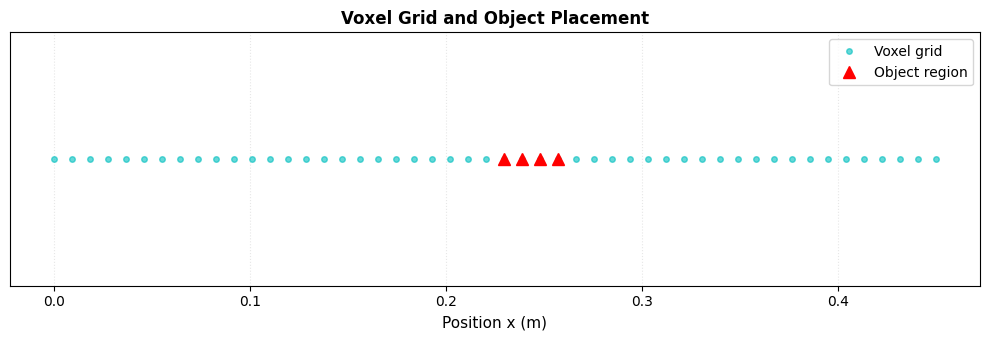

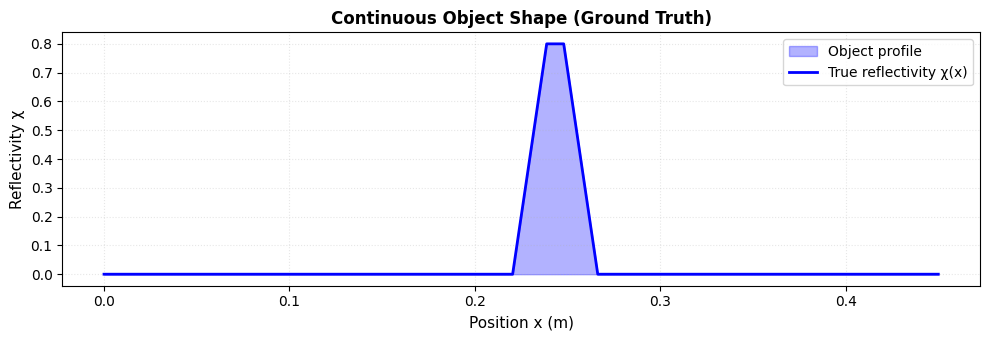


RUNNING COMPARATIVE EXPERIMENTS

Experiment 1: Single Antenna
Antenna positions: [0.0]
Matrix A shape: (20, 50)
Condition number: 4.4964e+08
Mean error: 7.962646e-02
Max error:  5.262846e-01


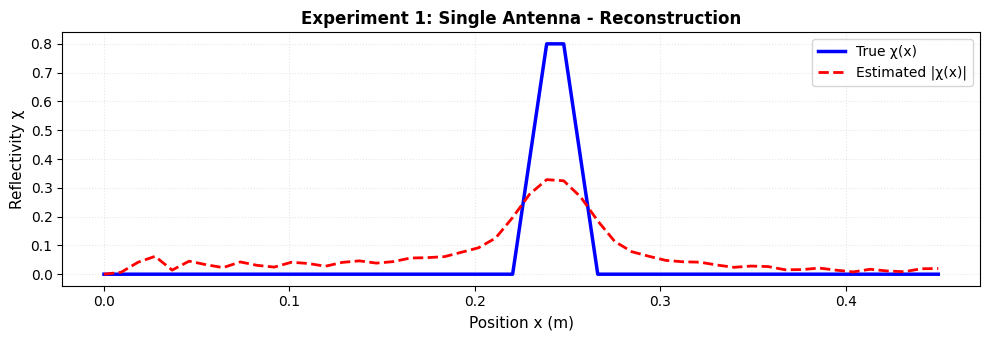

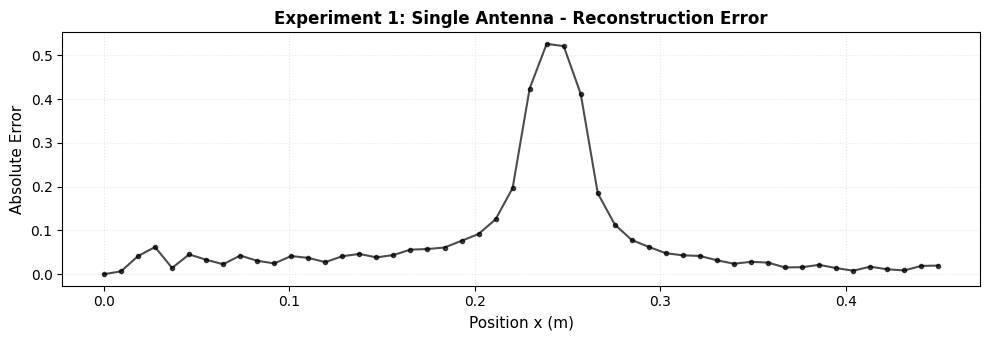

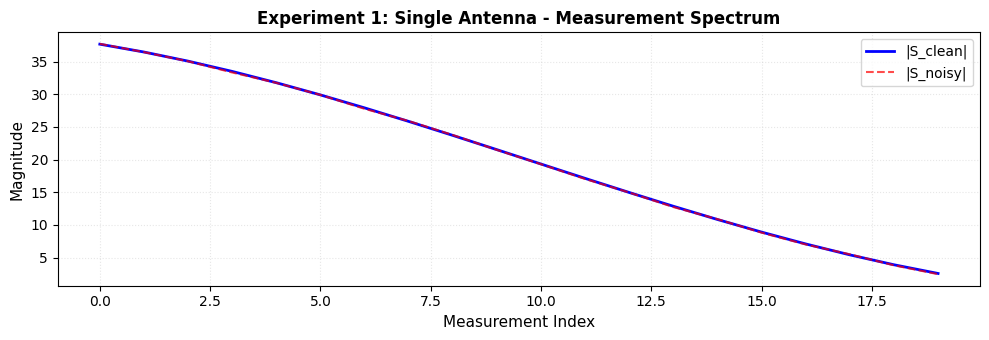

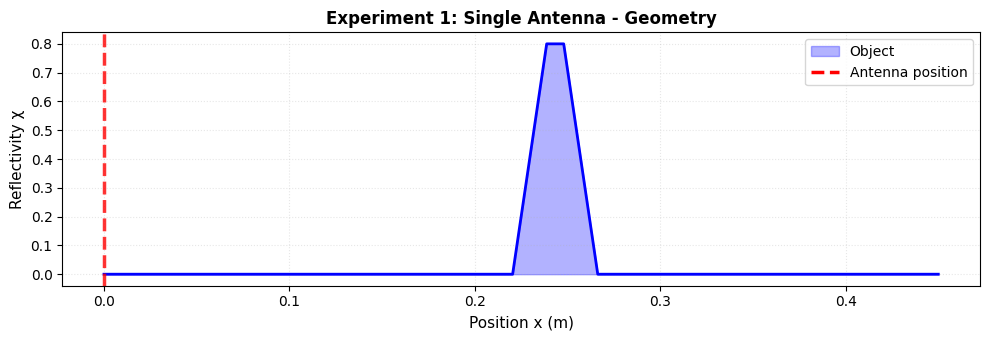

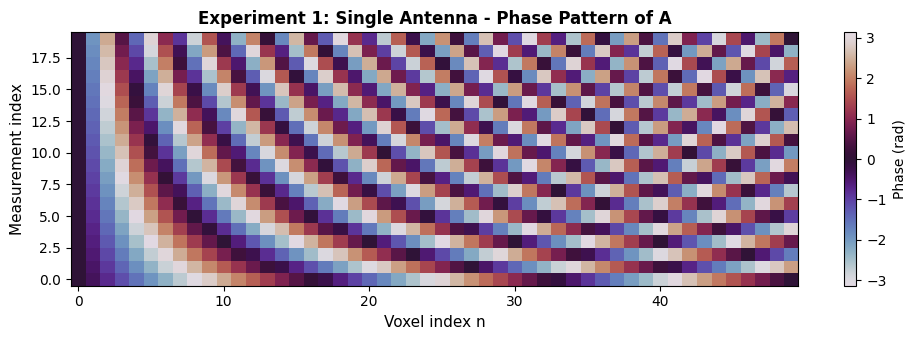


Phase Statistics (Single Antenna):
  Phase range: [-3.1382, 3.1382] rad
  Phase mean: -0.0440 rad
  Phase std: 1.8057 rad

Experiment 2: Double Assymetric
Antenna positions: [0.0, 0.3]
Matrix A shape: (80, 50)
Condition number: 9.1551e+14
Mean error: 3.031689e-02
Max error:  1.291073e-01


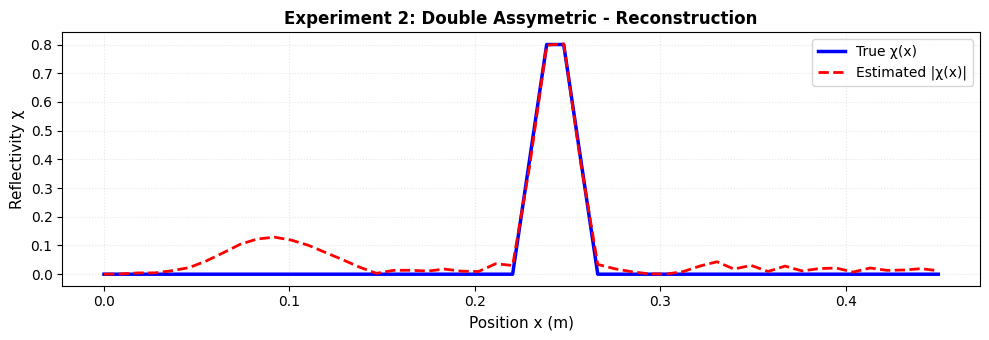

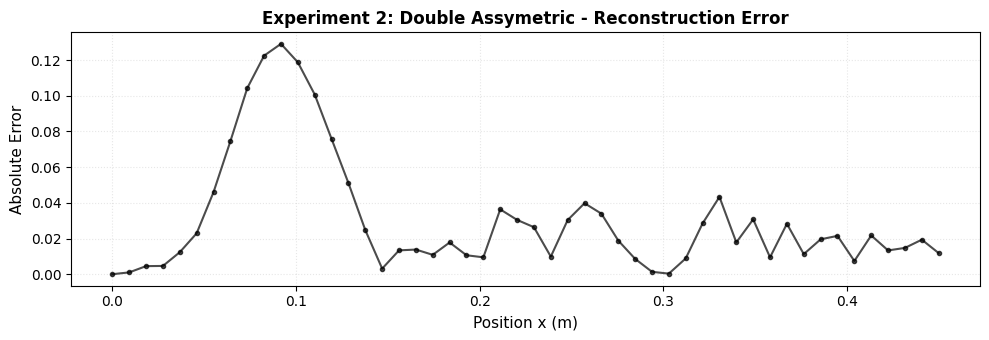

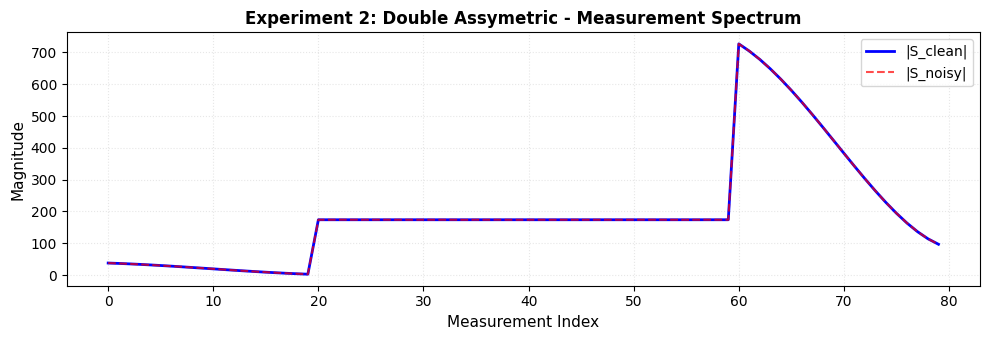

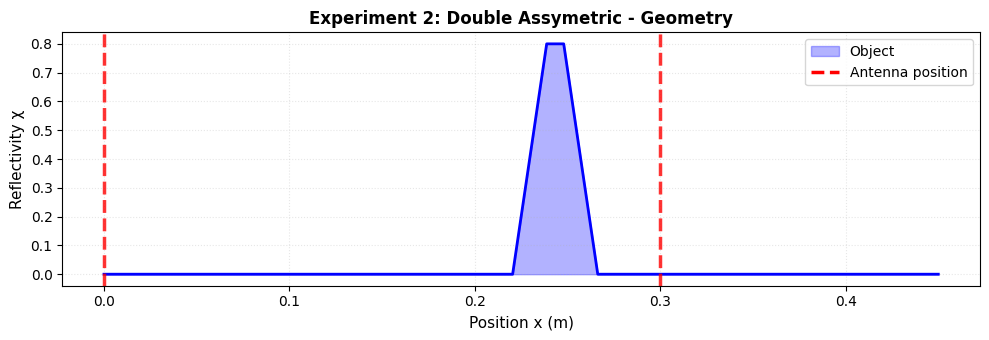

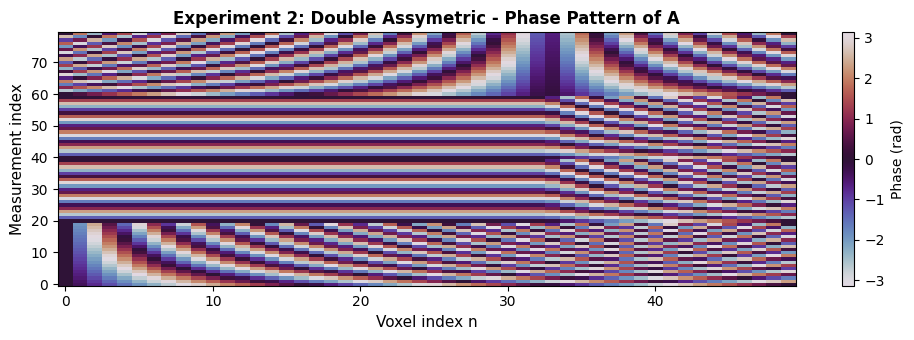


Phase Statistics (Double Assymetric):
  Phase range: [-3.1382, 3.1382] rad
  Phase mean: -0.0387 rad
  Phase std: 1.7949 rad

Experiment 3: Double Bad antenna
Antenna positions: [0.3, 0.45]
Matrix A shape: (80, 50)
Condition number: 4.6545e+19
Mean error: 9.677526e-02
Max error:  3.954487e-01


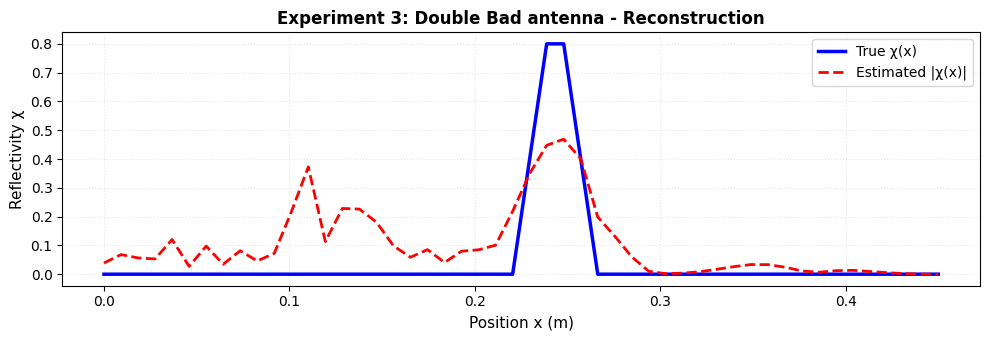

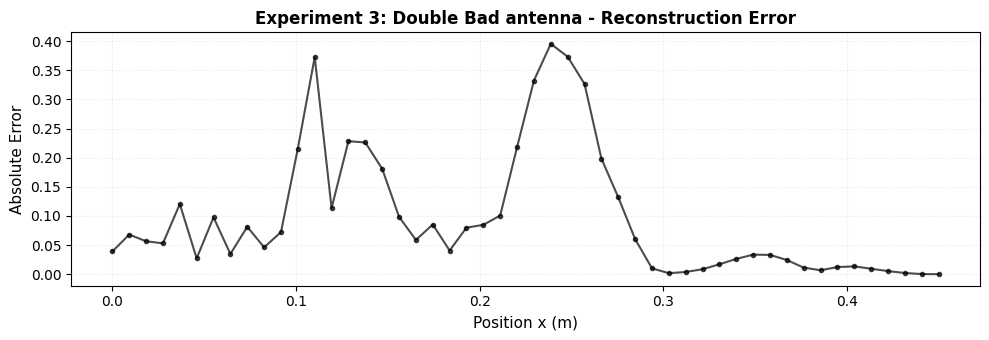

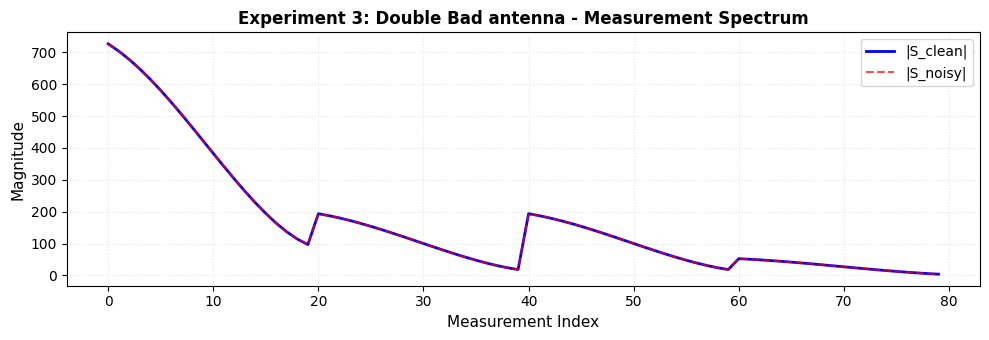

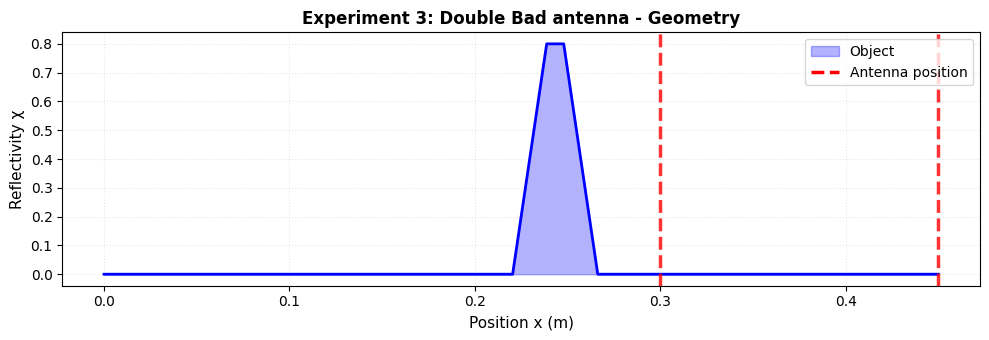

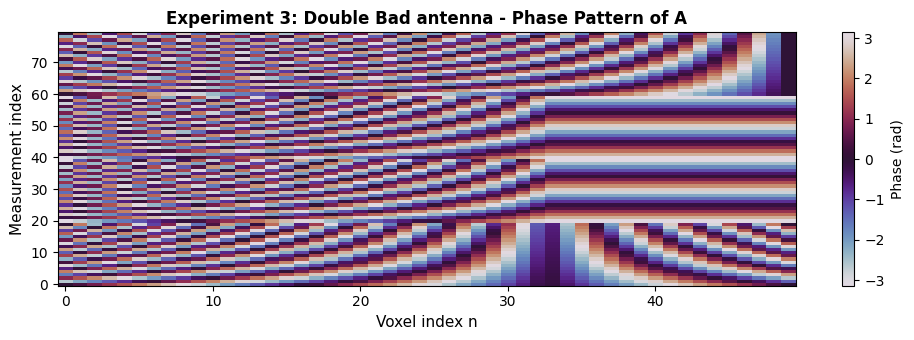


Phase Statistics (Double Bad antenna):
  Phase range: [-3.1416, 3.1416] rad
  Phase mean: 0.0210 rad
  Phase std: 1.8257 rad

Experiment 4: Triple antenna
Antenna positions: [0.0, 0.45, 0.23]
Matrix A shape: (180, 50)
Condition number: 2.4150e+10
Mean error: 3.786774e-02
Max error:  1.321861e-01


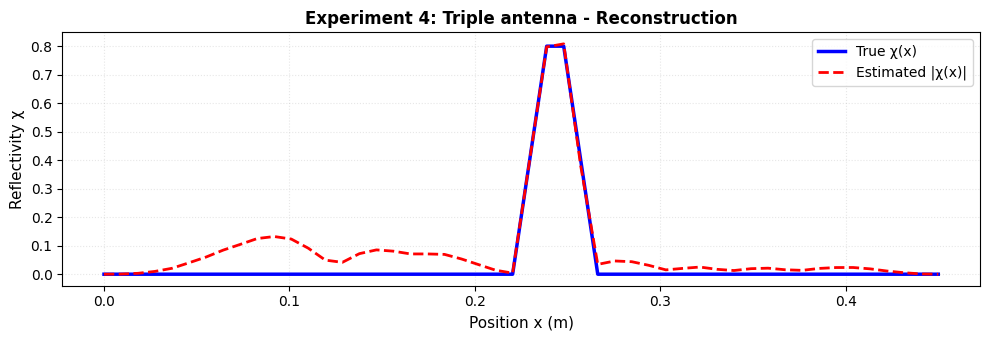

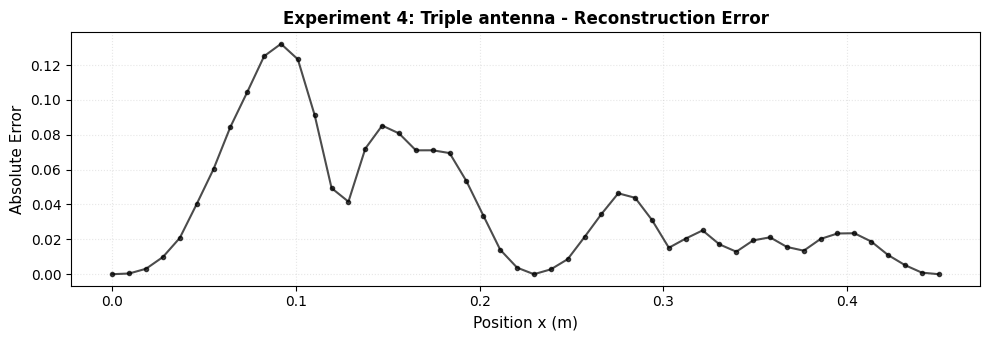

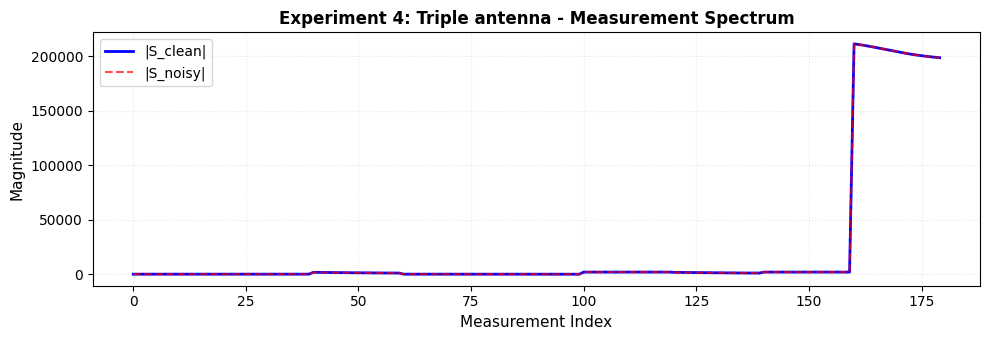

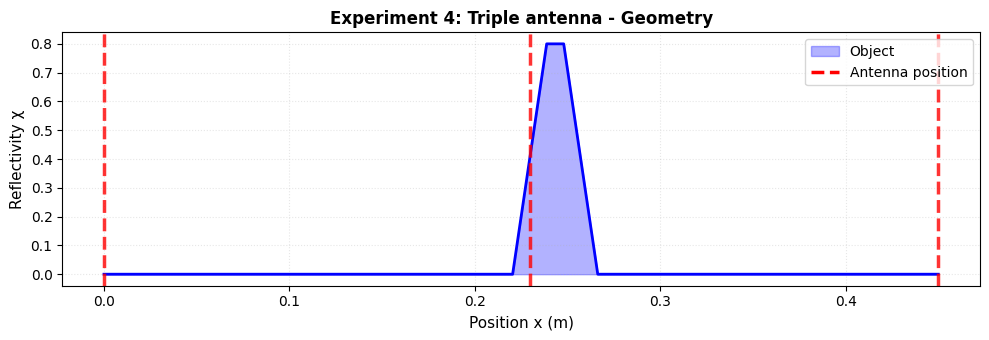

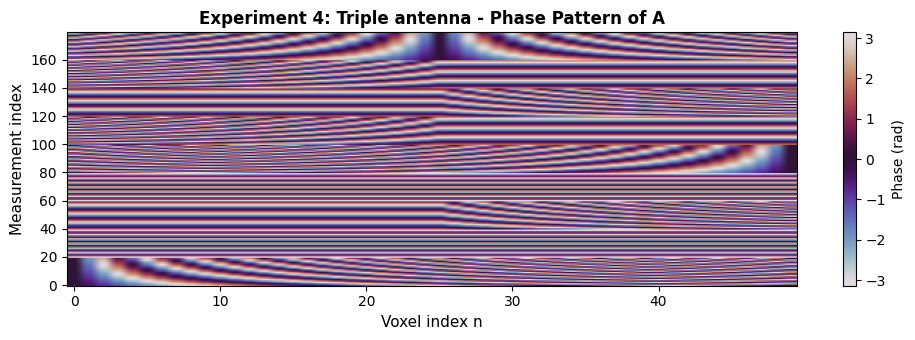


Phase Statistics (Triple antenna):
  Phase range: [-3.1416, 3.1407] rad
  Phase mean: -0.0242 rad
  Phase std: 1.8302 rad

COMPARISON SUMMARY

Reconstruction Error Metrics:
------------------------------------------------------------------------
Configuration                       Mean Error         Max Error         
------------------------------------------------------------------------
Single Antenna                      7.962646e-02       5.262846e-01      
Double Assymetric                   3.031689e-02       1.291073e-01      
Double Bad antenna                  9.677526e-02       3.954487e-01      
Triple antenna                      3.786774e-02       1.321861e-01      

Condition Numbers:
------------------------------------------------------------------------
Configuration                       Condition Number  
------------------------------------------------------------------------
Single Antenna                      4.4964e+08        
Double Assymetric                 

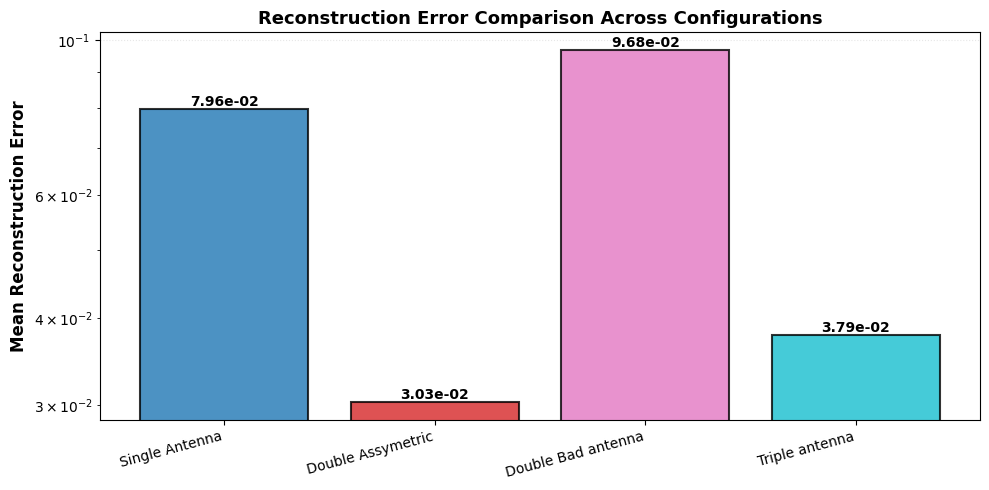


SIMULATION COMPLETE
All experiments have been run and visualized.


In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Keep array printing compact but readable for educational console output.
np.set_printoptions(precision=4, suppress=True)

# Make the demo reproducible so the noisy reconstruction is stable in a presentation.
np.random.seed(42)


def print_section_header(title: str) -> None:
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)


def print_experiment_header(exp_num: int, title: str) -> None:
    print("\n" + "=" * 72)
    print(f"Experiment {exp_num}: {title}")
    print("=" * 72)


# =============================================================================
# INTERACTIVE SETUP: USER INPUT SECTION
# =============================================================================
print_section_header("INTERACTIVE MICROWAVE IMAGING COMPARATIVE EXPERIMENT")
print("Configure the simulation parameters interactively.\n")

# --- 1) Number of voxels and spatial domain ---
print_section_header("Step 1: Spatial Domain Configuration")
while True:
    try:
        N = int(input("Enter number of voxels (default=50): ") or "50")
        if N < 5:
            print("  ERROR: Must have at least 5 voxels. Try again.")
            continue
        break
    except ValueError:
        print("  ERROR: Invalid input. Enter an integer.")

while True:
    try:
        x_max = float(input("Enter spatial domain upper limit in meters (default=0.45): ") or "0.45")
        if x_max <= 0:
            print("  ERROR: Upper limit must be positive. Try again.")
            continue
        break
    except ValueError:
        print("  ERROR: Invalid input. Enter a number.")

x = np.linspace(0, x_max, N)
print(f"✓ Voxel grid: {N} voxels from 0 to {x_max:.3f} m")


# --- 2) Object definition ---
print_section_header("Step 2: Object Definition")
print("Define one or more reflective objects in the spatial domain.")
print(f"Voxel range: {x[0]:.3f} to {x[-1]:.3f} m (indices 0 to {N-1})")

chi_true = np.zeros(N)
object_regions = []

while True:
    print("\nDefine object region:")
    while True:
        try:
            start_idx = int(input(f"  Start voxel index (0 to {N-1}): "))
            if 0 <= start_idx < N:
                break
            print(f"    ERROR: Must be between 0 and {N-1}.")
        except ValueError:
            print("    ERROR: Invalid input. Enter an integer.")

    while True:
        try:
            end_idx = int(input(f"  End voxel index (>={start_idx}): "))
            if end_idx >= start_idx and end_idx < N:
                break
            print(f"    ERROR: Must be >= {start_idx} and < {N}.")
        except ValueError:
            print("    ERROR: Invalid input. Enter an integer.")

    while True:
        try:
            chi_val = float(input("  Reflectivity χ value for this region (0.0 to 1.0): "))
            if 0 <= chi_val <= 1:
                break
            print("    ERROR: χ must be between 0 and 1.")
        except ValueError:
            print("    ERROR: Invalid input. Enter a number.")

    # Define shape: constant, Gaussian, or triangular
    print("  Shape options: (1) Constant, (2) Gaussian, (3) Triangular")
    while True:
        try:
            shape_choice = int(input("  Select shape (1/2/3, default=1): ") or "1")
            if shape_choice in [1, 2, 3]:
                break
            print("    ERROR: Enter 1, 2, or 3.")
        except ValueError:
            print("    ERROR: Invalid input.")

    region_indices = np.arange(start_idx, end_idx + 1)
    center_idx = (start_idx + end_idx) / 2.0

    if shape_choice == 1:
        # Constant
        chi_true[region_indices] = chi_val
        print(f"  ✓ Added constant region: χ={chi_val:.3f} at indices [{start_idx}, {end_idx}]")
    elif shape_choice == 2:
        # Gaussian
        sigma = (end_idx - start_idx) / 4.0 + 0.5
        for i in region_indices:
            chi_true[i] = chi_val * np.exp(-0.5 * ((i - center_idx) / sigma) ** 2)
        print(f"  ✓ Added Gaussian region: χ_peak={chi_val:.3f} at indices [{start_idx}, {end_idx}]")
    elif shape_choice == 3:
        # Triangular
        for i in region_indices:
            dist_from_center = np.abs(i - center_idx)
            max_dist = (end_idx - start_idx) / 2.0
            chi_true[i] = max(0, chi_val * (1 - dist_from_center / max_dist))
        print(f"  ✓ Added triangular region: χ_peak={chi_val:.3f} at indices [{start_idx}, {end_idx}]")

    object_regions.append((start_idx, end_idx, chi_val, shape_choice))

    add_more = input("\nAdd another object region? (y/n, default=n): ").strip().lower()
    if add_more != 'y':
        break

object_indices = np.where(chi_true > 0)[0]
print(f"\n✓ Object configuration complete. Object spans indices {object_indices[0]} to {object_indices[-1]}")


# --- 3) Frequency configuration ---
print_section_header("Step 3: Frequency Configuration")
while True:
    try:
        f_min = float(input("Enter minimum frequency in GHz (default=1.0): ") or "1.0")
        f_max = float(input("Enter maximum frequency in GHz (default=5.0): ") or "5.0")
        num_freq = int(input("Enter number of frequency points (default=20): ") or "20")
        if f_min < f_max and num_freq >= 3:
            break
        print("  ERROR: f_min < f_max and num_freq >= 3 required.")
    except ValueError:
        print("  ERROR: Invalid input.")

f = np.linspace(f_min * 1e9, f_max * 1e9, num_freq)
c = 3e8
k = 2 * np.pi * f / c
print(f"✓ Frequency range: {f_min:.1f} to {f_max:.1f} GHz ({num_freq} points)")


# --- 4) Noise and regularization ---
print_section_header("Step 4: Noise and Regularization")
while True:
    try:
        noise_level = float(input("Enter noise level as percentage (0-100%, default=8): ") or "8")
        lambda_reg = float(input("Enter regularization parameter λ (default=0.2): ") or "0.2")
        if 0 <= noise_level <= 100 and lambda_reg > 0:
            noise_level = noise_level / 100.0
            break
        print("  ERROR: noise in [0,100]% and λ > 0 required.")
    except ValueError:
        print("  ERROR: Invalid input.")

print(f"✓ Noise: {noise_level*100:.1f}%, Regularization: λ={lambda_reg:.3f}")


# --- 5) Antenna configurations ---
print_section_header("Step 5: Antenna Configurations")
print("Define antenna configurations to compare.\n")

antenna_configs = []
config_count = 0

while True:
    config_count += 1
    print(f"Configuration {config_count}:")
    config_name = input("  Name for this configuration (e.g., 'Single antenna'): ").strip()
    if not config_name:
        config_name = f"Configuration {config_count}"

    print(f"  Enter antenna positions (as space-separated values in meters)")
    print(f"  Example: 0.0 (single) or 0.0 0.45 (two antennas)")

    while True:
        try:
            antenna_str = input("  Antenna positions (e.g., 0.0 0.45): ").strip()
            antenna_pos = [float(pos) for pos in antenna_str.split()]

            # Validate positions
            if all(0 <= pos <= x_max for pos in antenna_pos):
                break
            print(f"    ERROR: Positions must be in [0, {x_max}].")
        except ValueError:
            print("    ERROR: Invalid input. Enter space-separated numbers.")

    antenna_configs.append({
        "name": config_name,
        "positions": antenna_pos,
    })
    print(f"  ✓ Added: {config_name} with antennas at {antenna_pos}")

    add_more = input("\nAdd another configuration? (y/n, default=n): ").strip().lower()
    if add_more != 'y':
        break

print(f"\n✓ Defined {len(antenna_configs)} antenna configurations")


# =============================================================================
# DEFINE COMMON FUNCTIONS
# =============================================================================
def simulate_S(antenna_positions, x, chi_true, f, k, noise_level):
    """Simulate noisy measurement vector S."""
    num_antennas = len(antenna_positions)
    num_freq = len(f)
    num_measurements = num_antennas * num_antennas * num_freq
    S_clean = np.zeros(num_measurements, dtype=complex)

    for tx_idx, tx_pos in enumerate(antenna_positions):
        for rx_idx, rx_pos in enumerate(antenna_positions):
            for i in range(num_freq):
                row_idx = tx_idx * (num_antennas * num_freq) + rx_idx * num_freq + i
                for n in range(len(x)):
                    r_tx = np.abs(x[n] - tx_pos)
                    r_rx = np.abs(x[n] - rx_pos)
                    contribution = (
                        chi_true[n]
                        * (1 / (r_tx + 1e-3))
                        * (1 / (r_rx + 1e-3))
                        * np.exp(-1j * k[i] * (r_tx + r_rx))
                    )
                    S_clean[row_idx] += contribution

    noise = noise_level * (
        np.random.randn(*S_clean.shape) + 1j * np.random.randn(*S_clean.shape)
    )
    S_noisy = S_clean + noise
    return S_clean, S_noisy


def build_A(antenna_positions, x, f, k):
    """Build system matrix A."""
    num_antennas = len(antenna_positions)
    num_freq = len(f)
    num_measurements = num_antennas * num_antennas * num_freq
    N = len(x)
    A = np.zeros((num_measurements, N), dtype=complex)

    for tx_idx, tx_pos in enumerate(antenna_positions):
        for rx_idx, rx_pos in enumerate(antenna_positions):
            for i in range(num_freq):
                row_idx = tx_idx * (num_antennas * num_freq) + rx_idx * num_freq + i
                for n in range(N):
                    r_tx = np.abs(x[n] - tx_pos)
                    r_rx = np.abs(x[n] - rx_pos)
                    A[row_idx, n] = (
                        (1 / (r_tx + 1e-3))
                        * (1 / (r_rx + 1e-3))
                        * np.exp(-1j * k[i] * (r_tx + r_rx))
                    )
    return A


def reconstruct(A, S_noisy, lambda_reg, N):
    """Reconstruct chi using regularized least squares."""
    identity = np.eye(N)
    chi_est = (
        np.linalg.inv(A.conj().T @ A + lambda_reg * identity)
        @ A.conj().T
        @ S_noisy
    )
    return chi_est


def compute_error(chi_true, chi_est):
    """Compute reconstruction error metrics."""
    error = np.abs(chi_true - chi_est)
    mean_error = np.mean(error)
    max_error = np.max(error)
    return error, mean_error, max_error


# =============================================================================
# SETUP VISUALIZATION
# =============================================================================
print_section_header("SETUP: Global Voxel Grid and Object")
print(f"Number of voxels: {N}")
print(f"Voxel range: {x[0]:.4f} m to {x[-1]:.4f} m")
print(f"Object support indices: {object_indices.tolist() if len(object_indices) > 0 else 'None'}")
print(f"Frequency range: {f[0]/1e9:.1f} GHz to {f[-1]/1e9:.1f} GHz")

plt.figure(figsize=(10, 3.5))
plt.plot(x, np.zeros_like(x), "co", alpha=0.6, markersize=4, label="Voxel grid")
if len(object_indices) > 0:
    plt.plot(x[object_indices], np.zeros_like(object_indices, dtype=float), "r^", markersize=8, label="Object region")
plt.yticks([])
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("")
plt.title("Voxel Grid and Object Placement", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3, linestyle=":")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 3.5))
plt.fill_between(x, 0, chi_true, alpha=0.3, color="blue", label="Object profile")
plt.plot(x, chi_true, "b-", linewidth=2, label="True reflectivity χ(x)")
plt.xlabel("Position x (m)", fontsize=11)
plt.ylabel("Reflectivity χ", fontsize=11)
plt.title("Continuous Object Shape (Ground Truth)", fontsize=12, fontweight="bold")
plt.grid(alpha=0.3, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# STORAGE FOR RESULTS
# =============================================================================
results = {}


# =============================================================================
# RUN ALL EXPERIMENTS
# =============================================================================
print_section_header("RUNNING COMPARATIVE EXPERIMENTS")

for exp_idx, config in enumerate(antenna_configs, start=1):
    config_name = config["name"]
    antenna_positions = config["positions"]

    print_experiment_header(exp_idx, config_name)
    print(f"Antenna positions: {antenna_positions}")

    # Simulate
    S_clean, S_noisy = simulate_S(antenna_positions, x, chi_true, f, k, noise_level)
    A = build_A(antenna_positions, x, f, k)
    chi_est = reconstruct(A, S_noisy, lambda_reg, N)
    error, mean_err, max_err = compute_error(chi_true, chi_est)

    print(f"Matrix A shape: {A.shape}")
    print(f"Condition number: {np.linalg.cond(A):.4e}")
    print(f"Mean error: {mean_err:.6e}")
    print(f"Max error:  {max_err:.6e}")

    # Plot 1: Ground truth vs reconstruction
    plt.figure(figsize=(10, 3.5))
    plt.plot(x, chi_true, "b-", linewidth=2.5, label="True χ(x)")
    plt.plot(x, np.abs(chi_est), "r--", linewidth=2, label="Estimated |χ(x)|")
    plt.xlabel("Position x (m)", fontsize=11)
    plt.ylabel("Reflectivity χ", fontsize=11)
    plt.title(f"Experiment {exp_idx}: {config_name} - Reconstruction", fontsize=12, fontweight="bold")
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3, linestyle=":")
    plt.tight_layout()
    plt.show()

    # Plot 2: Error
    plt.figure(figsize=(10, 3.5))
    plt.plot(x, error, "k-o", linewidth=1.5, markersize=3, alpha=0.7)
    plt.xlabel("Position x (m)", fontsize=11)
    plt.ylabel("Absolute Error", fontsize=11)
    plt.title(f"Experiment {exp_idx}: {config_name} - Reconstruction Error", fontsize=12, fontweight="bold")
    plt.grid(alpha=0.3, linestyle=":")
    plt.tight_layout()
    plt.show()

    # Plot 3: Measurement spectrum
    plt.figure(figsize=(10, 3.5))
    plt.plot(np.abs(S_clean), "b-", linewidth=2, label="|S_clean|")
    plt.plot(np.abs(S_noisy), "r--", linewidth=1.5, alpha=0.7, label="|S_noisy|")
    plt.xlabel("Measurement Index", fontsize=11)
    plt.ylabel("Magnitude", fontsize=11)
    plt.title(f"Experiment {exp_idx}: {config_name} - Measurement Spectrum", fontsize=12, fontweight="bold")
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3, linestyle=":")
    plt.tight_layout()
    plt.show()

    # Plot 4: Antenna positions relative to object
    plt.figure(figsize=(10, 3.5))
    plt.fill_between(x, 0, chi_true, alpha=0.3, color="blue", label="Object")
    plt.plot(x, chi_true, "b-", linewidth=2)
    for ant_pos in antenna_positions:
        plt.axvline(ant_pos, color="red", linestyle="--", linewidth=2.5, alpha=0.8)
    plt.plot([], [], "r--", linewidth=2.5, label="Antenna position")
    plt.xlabel("Position x (m)", fontsize=11)
    plt.ylabel("Reflectivity χ", fontsize=11)
    plt.title(f"Experiment {exp_idx}: {config_name} - Geometry", fontsize=12, fontweight="bold")
    plt.legend(fontsize=10, loc="upper right")
    plt.grid(alpha=0.3, linestyle=":")
    plt.tight_layout()
    plt.show()

    # Plot 5: Phase pattern of system matrix
    plt.figure(figsize=(10, 3.5))
    plt.imshow(np.angle(A), cmap="twilight", aspect="auto", origin="lower")
    plt.colorbar(label="Phase (rad)")
    plt.xlabel("Voxel index n", fontsize=11)
    plt.ylabel("Measurement index", fontsize=11)
    plt.title(f"Experiment {exp_idx}: {config_name} - Phase Pattern of A", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print(f"\nPhase Statistics ({config_name}):")
    print(f"  Phase range: [{np.min(np.angle(A)):.4f}, {np.max(np.angle(A)):.4f}] rad")
    print(f"  Phase mean: {np.mean(np.angle(A)):.4f} rad")
    print(f"  Phase std: {np.std(np.angle(A)):.4f} rad")

    results[config_name] = {
        "mean_error": mean_err,
        "max_error": max_err,
        "cond_A": np.linalg.cond(A),
    }


# =============================================================================
# COMPARISON SUMMARY
# =============================================================================
print_section_header("COMPARISON SUMMARY")
print("\nReconstruction Error Metrics:")
print("-" * 72)
print(f"{'Configuration':<35} {'Mean Error':<18} {'Max Error':<18}")
print("-" * 72)
for config_name, metrics in results.items():
    print(f"{config_name:<35} {metrics['mean_error']:<18.6e} {metrics['max_error']:<18.6e}")

print("\nCondition Numbers:")
print("-" * 72)
print(f"{'Configuration':<35} {'Condition Number':<18}")
print("-" * 72)
for config_name, metrics in results.items():
    print(f"{config_name:<35} {metrics['cond_A']:<18.4e}")

# Calculate improvements
if len(results) > 1:
    errors = list(results.values())
    baseline_error = errors[0]["mean_error"]
    print("\nImprovement Analysis:")
    print("-" * 72)
    for i, (config_name, metrics) in enumerate(results.items()):
        if i == 0:
            print(f"{config_name:<35} (baseline)")
        else:
            improvement = 100.0 * (baseline_error - metrics["mean_error"]) / (baseline_error + 1e-12)
            print(f"{config_name:<35} {improvement:+.2f}% vs baseline")


# =============================================================================
# FINAL COMPARISON PLOT
# =============================================================================
if len(results) > 1:
    config_names = list(results.keys())
    mean_errors = [results[name]["mean_error"] for name in config_names]

    plt.figure(figsize=(10, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(config_names)))
    bars = plt.bar(range(len(config_names)), mean_errors, color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
    plt.xticks(range(len(config_names)), config_names, rotation=15, ha='right')
    plt.ylabel("Mean Reconstruction Error", fontsize=12, fontweight="bold")
    plt.title("Reconstruction Error Comparison Across Configurations", fontsize=13, fontweight="bold")
    plt.yscale("log")
    plt.grid(alpha=0.3, linestyle=":", axis="y")

    # Add value labels on bars
    for bar, err in zip(bars, mean_errors):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{err:.2e}',
                 ha='center', va='bottom', fontsize=10, fontweight="bold")

    plt.tight_layout()
    plt.show()


print_section_header("SIMULATION COMPLETE")
print("All experiments have been run and visualized.")
print("=" * 72)
